# AI-Driven Workplace Incident Analysis and Prediction Using Machine Learning

### Group 5 2026 Members Name:

* 1. Vikash Basfore
* 2. Kavya Radheshwar
* 3. Lokeswari
* 4. Mumtaz Khan
* 5. Divyashree. C
* 6. R Haridharan


### Objective: 

* Identify  hazardous/high-risk jobs, industries, and incident types to improve safety management.

* This objective focuses on analyzing severity indicators such as total injuries, fatalities, days away from work (DAFW), and restricted work cases to rank industries. A standardized AI model will be developed to evaluate industry-wise hazard levels and track safety performance over time.


### Problem Statement:
* Workplace injuries remain a persistent challenge in sectors such as manufacturing, construction, transportation, and healthcare etc. According to reports from OSHA and labour statistics agencies, occupational injuries result in significant financial losses, productivity decline, and long-term employee health impacts. While large volumes of injury data are collected annually, much of this information is underutilized for predictive decision-making.
* Traditional safety management systems primarily depend on compliance reporting, periodic audits, and descriptive statistics. These methods provide historical insights but fail to identify hidden patterns or forecast future risk levels. As a result, organizations often respond to incidents rather than prevent them.

### Important Libraries:- 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


import warnings
warnings.filterwarnings('ignore')

##### Load the Data set

In [2]:
data = pd.read_csv('ITA Case Detail Data 2024 through 08-31-2025.csv')
df = data.copy()
df.head()

,id,establishment_id,establishment_name,ein,company_name,street_address,city,state,zip_code,naics_code,...,time_unknown,date_of_death,created_timestamp,year_filing_for,NEW_NAR_WHAT_HAPPENED,NEW_NAR_BEFORE_INCIDENT,NEW_INCIDENT_LOCATION,NEW_NAR_INJURY_ILLNESS,NEW_NAR_OBJECT_SUBSTANCE,NEW_INCIDENT_DESCRIPTION
0,903263,858641,Lutheran Home of the Good Shepherd,450277267.0,Lutheran Home of the Good Shepherd,"LHGS, 1226 1st Avenue N",New Rockford,ND,58356,623110,...,1.0,NaN,01JAN25:15:23:00,2024,Contact with [REDACTED] Positive Resident,unknown,LHGS- contact with positive resident,Respiratory Condition,Covid,[REDACTED]
1,903264,858641,Lutheran Home of the Good Shepherd,450277267.0,Lutheran Home of the Good Shepherd,"LHGS, 1226 1st Avenue N",New Rockford,ND,58356,623110,...,1.0,NaN,01JAN25:15:25:00,2024,Contact with Covid Positive Employee,unknown,LHGS- contact with positive Covid staff,Respiratory Condition,Covid,[REDACTED]
2,903265,858641,Lutheran Home of the Good Shepherd,450277267.0,Lutheran Home of the Good Shepherd,"LHGS, 1226 1st Avenue N",New Rockford,ND,58356,623110,...,1.0,NaN,01JAN25:15:29:00,2024,Worked in [REDACTED] residential area,unknown,Worked in Covid Positive residential area,Covid,Respiratory Condition,[REDACTED]
3,903266,858641,Lutheran Home of the Good Shepherd,450277267.0,Lutheran Home of the Good Shepherd,"LHGS, 1226 1st Avenue N",New Rockford,ND,58356,623110,...,1.0,NaN,01JAN25:15:31:00,2024,Worked in [REDACTED] residential area,unknown,Worked in Covid Positive residential area,Respiratory Condition,Covid,[REDACTED]
4,903267,858641,Lutheran Home of the Good Shepherd,450277267.0,Lutheran Home of the Good Shepherd,"LHGS, 1226 1st Avenue N",New Rockford,ND,58356,623110,...,1.0,NaN,01JAN25:15:34:00,2024,Worked in [REDACTED] residential area,unknown,Worked in Covid Positive residential area,Respiratory Condition,Covid,[REDACTED]


In [3]:
# Original Before doing anythink
# Basic shape
print('Rows: ', df.shape[0])
print('Columns: ', df.shape[1])
print()
# Data info
print(df.info())
print()
# Summary statistics
df.describe().T

Rows:  686806
Columns:  39

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 686806 entries, 0 to 686805
Data columns (total 39 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   id                        686806 non-null  int64  
 1   establishment_id          686806 non-null  int64  
 2   establishment_name        686806 non-null  object 
 3   ein                       626651 non-null  float64
 4   company_name              650723 non-null  object 
 5   street_address            686806 non-null  object 
 6   city                      686806 non-null  object 
 7   state                     686806 non-null  object 
 8   zip_code                  686806 non-null  int64  
 9   naics_code                686806 non-null  int64  
 10  naics_year                686806 non-null  int64  
 11  industry_description      634366 non-null  object 
 12  establishment_type        685782 non-null  float64
 13  size            

,count,mean,std,min,25%,50%,75%,max
id,686806.0,1.285538e+06,2.202935e+05,903263.0,1.095895e+06,1.287226e+06,1.473157e+06,1.668232e+06
establishment_id,686806.0,9.876351e+05,3.818698e+05,41942.0,8.561690e+05,1.105313e+06,1.307103e+06,1.419711e+06
ein,626651.0,5.570715e+08,2.642316e+08,0.0,3.625904e+08,5.824801e+08,8.124479e+08,1.000000e+09
zip_code,686806.0,1.873347e+07,1.114410e+08,603.0,2.837600e+04,5.103100e+04,8.405800e+04,9.970132e+08
naics_code,686806.0,5.039491e+05,1.355234e+05,111110.0,4.451100e+05,4.921100e+05,6.221100e+05,9.512990e+05
naics_year,686806.0,2.016816e+03,4.979498e+00,2012.0,2.012000e+03,2.012000e+03,2.022000e+03,2.022000e+03
establishment_type,685782.0,1.105345e+00,4.065922e-01,1.0,1.000000e+00,1.000000e+00,1.000000e+00,3.000000e+00
size,686806.0,9.222221e+00,8.899525e+00,1.0,3.000000e+00,3.000000e+00,2.200000e+01,2.200000e+01
annual_average_employees,686806.0,3.304729e+03,1.639469e+05,0.0,1.720000e+02,3.960000e+02,1.534000e+03,4.109260e+07
total_hours_worked,686806.0,2.889163e+07,4.656180e+09,0.0,2.782570e+05,6.470310e+05,2.474459e+06,8.628470e+11


#### Dropping unnecessary identifier and timestamp columns that are not useful for analysis

In [4]:
cols_to_drop = [
    'id',
    'establishment_id',
    'ein',
    'case_number',
    'created_timestamp'
]

df = df.drop(columns=cols_to_drop)

#### Convert Date Column

In [5]:
df['date_of_incident'] = pd.to_datetime(df['date_of_incident'], errors='coerce')

df['incident_year'] = df['date_of_incident'].dt.year
df['incident_month'] = df['date_of_incident'].dt.month
df.head()

,establishment_name,company_name,street_address,city,state,zip_code,naics_code,naics_year,industry_description,establishment_type,...,date_of_death,year_filing_for,NEW_NAR_WHAT_HAPPENED,NEW_NAR_BEFORE_INCIDENT,NEW_INCIDENT_LOCATION,NEW_NAR_INJURY_ILLNESS,NEW_NAR_OBJECT_SUBSTANCE,NEW_INCIDENT_DESCRIPTION,incident_year,incident_month
0,Lutheran Home of the Good Shepherd,Lutheran Home of the Good Shepherd,"LHGS, 1226 1st Avenue N",New Rockford,ND,58356,623110,2012,Nursing homes,2.0,...,NaN,2024,Contact with [REDACTED] Positive Resident,unknown,LHGS- contact with positive resident,Respiratory Condition,Covid,[REDACTED],2024.0,3.0
1,Lutheran Home of the Good Shepherd,Lutheran Home of the Good Shepherd,"LHGS, 1226 1st Avenue N",New Rockford,ND,58356,623110,2012,Nursing homes,2.0,...,NaN,2024,Contact with Covid Positive Employee,unknown,LHGS- contact with positive Covid staff,Respiratory Condition,Covid,[REDACTED],2024.0,3.0
2,Lutheran Home of the Good Shepherd,Lutheran Home of the Good Shepherd,"LHGS, 1226 1st Avenue N",New Rockford,ND,58356,623110,2012,Nursing homes,2.0,...,NaN,2024,Worked in [REDACTED] residential area,unknown,Worked in Covid Positive residential area,Covid,Respiratory Condition,[REDACTED],2024.0,3.0
3,Lutheran Home of the Good Shepherd,Lutheran Home of the Good Shepherd,"LHGS, 1226 1st Avenue N",New Rockford,ND,58356,623110,2012,Nursing homes,2.0,...,NaN,2024,Worked in [REDACTED] residential area,unknown,Worked in Covid Positive residential area,Respiratory Condition,Covid,[REDACTED],2024.0,3.0
4,Lutheran Home of the Good Shepherd,Lutheran Home of the Good Shepherd,"LHGS, 1226 1st Avenue N",New Rockford,ND,58356,623110,2012,Nursing homes,2.0,...,NaN,2024,Worked in [REDACTED] residential area,unknown,Worked in Covid Positive residential area,Respiratory Condition,Covid,[REDACTED],2024.0,3.0


#### Missing Value Analysis

In [6]:
# Missing value count and how much percent it takes

missing = df.isnull().sum().sort_values(ascending=False)
missing_percent = (df.isnull().sum()/len(df))*100

missing_df = pd.DataFrame({
    "Missing_Count": missing,
    "Missing_Percent": missing_percent
})

missing_df[missing_df["Missing_Count"] > 0]


,Missing_Count,Missing_Percent
NEW_INCIDENT_DESCRIPTION,645,0.093913
NEW_INCIDENT_LOCATION,223,0.032469
NEW_NAR_BEFORE_INCIDENT,1106,0.161035
NEW_NAR_INJURY_ILLNESS,560,0.081537
NEW_NAR_OBJECT_SUBSTANCE,6710,0.976986
NEW_NAR_WHAT_HAPPENED,691,0.100611
company_name,36083,5.253740
date_of_death,686607,99.971025
date_of_incident,8,0.001165
establishment_type,1024,0.149096


#### Missing value Tratement: 

In [7]:
# Drop rows where important SOC and incident date information is missing (less than > 10 null values)
df = df.dropna(subset=[
    'soc_code',
    'soc_description',
    'soc_probability',
    'soc_reviewed', 
    'date_of_incident'
])




# Drop column with extremely high missing values (~99.97%)
df.drop(columns='date_of_death', axis=1, inplace=True)




# Fill very small missing values in narrative text columns with "Unknown"
df['NEW_INCIDENT_DESCRIPTION'].fillna("Unknown", inplace=True)
df['NEW_NAR_BEFORE_INCIDENT'].fillna("Unknown", inplace=True)
df['NEW_NAR_WHAT_HAPPENED'].fillna("Unknown", inplace=True)




# Fill location and injury description with the most frequent value (mode)
df['NEW_INCIDENT_LOCATION'].fillna(df['NEW_INCIDENT_LOCATION'].mode()[0], inplace=True)
df['NEW_NAR_INJURY_ILLNESS'].fillna(df['NEW_NAR_INJURY_ILLNESS'].mode()[0], inplace=True)




# Preserve row information by labeling missing companies as "Unknown Company"
df['company_name'].fillna("Unknown Company", inplace=True)




# Fill missing industry description using NAICS code mapping
industry_map = df.dropna(subset=['industry_description']) \
                 .drop_duplicates('naics_code') \
                 .set_index('naics_code')['industry_description'] \
                 .to_dict()

df['industry_description'] = df['industry_description'].fillna(
    df['naics_code'].map(industry_map)
)
# Drop rows where industry description is still missing after mapping
df.dropna(subset=['industry_description'], inplace=True)


# Fill missing binary indicator using the most frequent value
df['time_unknown'].fillna(df['time_unknown'].mode()[0], inplace=True)



# Replace missing job titles with "Unknown" and standardize text format
df['job_description'] = df['job_description'].fillna("Unknown")
df['job_description'] = df['job_description'].str.lower().str.strip() # Convert text to lowercase # Remove leading and trailing spaces




# # Clean  time_of_incident column and convert to datetime
df['time_of_incident'] = df['time_of_incident'].str.replace('.000','', regex=False) # regex: treat .000 as normal text, not a regular expression.
df['time_of_incident'] = pd.to_datetime(df['time_of_incident'], errors='coerce') # coerce : If a value cannot be converted, pandas will replace it with NaN (missing value)
# # Extract start hour feature for analysis
df['incident_hour'] = df['time_of_incident'].dt.hour
# # Fill missing start hours using the median hour
df['incident_hour'] = df['incident_hour'].fillna(df['incident_hour'].median())
# drop original column
df.drop(columns=['time_of_incident'], inplace=True)




# Clean and standardize object/substance column values
df['NEW_NAR_OBJECT_SUBSTANCE'] = df['NEW_NAR_OBJECT_SUBSTANCE'].replace(
    ['N A','blank','NA','None','null'], 'Unknown'
).fillna('Unknown').str.lower().str.strip()



# Fill missing establishment type and convert numeric codes to readable labels
df['establishment_type'] = df['establishment_type'].fillna(
    df['establishment_type'].mode()[0]
).astype(int)




# Clean time_started_work column and convert to datetime
df['time_started_work'] = df['time_started_work'].str.replace('.000','', regex=False)
df['time_started_work'] = pd.to_datetime(df['time_started_work'], errors='coerce')
# Extract start hour feature for analysis
df['start_hour'] = df['time_started_work'].dt.hour
# Fill missing start hours using the median hour
df['start_hour'] = df['start_hour'].fillna(df['start_hour'].median())
# Drop original time column since start_hour is used instead
df.drop(columns=['time_started_work'], inplace=True)

####  Checking the null values after handling:

In [8]:
df.isnull().sum().sum()

np.int64(0)

#### Duplicates Checking

In [9]:
# after handling the null values we find 2075 duplicates values
df.duplicated().sum()  # 2075 rows are duplicated

np.int64(2075)

In [10]:
# handling the duplicates values
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

#### After removing unnecessary columns, null values and duplicates

In [11]:
# Basic shape
print('Rows: ',df.shape[0])
print('columns: ', df.shape[1])
print()

# Data info
print(df.info())
print()
# Summary statistics
df.describe().T

Rows:  683962
columns:  35

<class 'pandas.core.frame.DataFrame'>
Index: 683962 entries, 1 to 686805
Data columns (total 35 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   establishment_name        683962 non-null  object        
 1   company_name              683962 non-null  object        
 2   street_address            683962 non-null  object        
 3   city                      683962 non-null  object        
 4   state                     683962 non-null  object        
 5   zip_code                  683962 non-null  int64         
 6   naics_code                683962 non-null  int64         
 7   naics_year                683962 non-null  int64         
 8   industry_description      683962 non-null  object        
 9   establishment_type        683962 non-null  int64         
 10  size                      683962 non-null  int64         
 11  annual_average_employees  683962 non-null 

,count,mean,min,25%,50%,75%,max,std
zip_code,683962.0,18567642.756068,603.0,28458.0,51031.0,84044.0,997013166.0,110867990.135812
naics_code,683962.0,503940.070469,111110.0,445110.0,492110.0,622110.0,951299.0,135604.974241
naics_year,683962.0,2016.804828,2012.0,2012.0,2012.0,2022.0,2022.0,4.979808
establishment_type,683962.0,1.105601,1.0,1.0,1.0,1.0,3.0,0.407051
size,683962.0,9.230688,1.0,3.0,3.0,22.0,22.0,8.902976
annual_average_employees,683962.0,3314.428717,0.0,172.0,395.0,1536.0,41092597.0,164287.35971
total_hours_worked,683962.0,29005850.511467,0.0,278075.0,647530.0,2478083.0,862847000000.0,4665850226.00117
soc_reviewed,683962.0,0.953328,0.0,0.0,1.0,1.0,2.0,0.708059
soc_probability,683962.0,1.264253,0.0,0.0,0.992367,0.999991,5.0,1.554664
date_of_incident,683962,2024-06-29 17:12:47.274204928,2023-01-02 00:00:00,2024-04-02 00:00:00,2024-07-02 00:00:00,2024-09-26 00:00:00,2025-08-15 00:00:00,NaN


### Data Preparation and Type Correction


Before performing further analysis and modeling, several preprocessing steps are required. Some variables are stored with incorrect data types, some contain extreme outliers, and one column contains no variation. Correcting these issues improves the quality of analysis and prevents misleading results.

#### 1. Remove Constant Column
The column year_filing_for contains only one value (2024) for all records. Since it has no variation, it does not provide any useful information for analysis or modeling and can be removed.

In [12]:
df.drop('year_filing_for', axis=1, inplace=True)

#### 2. Convert Code Variables to Categorical
Some variables are stored as numeric values but actually represent categories or codes rather than quantities. Treating them as numeric could lead to incorrect statistical interpretations. Therefore, they are converted to categorical variables.

In [13]:
cat_cols = [
'zip_code',
'naics_code',
'naics_year',
'soc_reviewed',
'incident_outcome',
'type_of_incident',
'time_unknown',
'incident_year',
'incident_month',
'establishment_type'
]

for col in cat_cols:
    df[col] = df[col].astype('object')

### 3. Handle Extreme Outliers
Some numerical variables contain extremely large values that may distort statistical analysis and visualizations. These extreme values may occur due to data entry errors or aggregated reporting. To reduce their impact, values above the 99th percentile are capped.

Columns affected:

annual_average_employees

total_hours_worked

In [14]:
df['annual_average_employees'] = df['annual_average_employees'].clip(
    upper=df['annual_average_employees'].quantile(0.99)
)

df['total_hours_worked'] = df['total_hours_worked'].clip(
    upper=df['total_hours_worked'].quantile(0.99)
)

#### 4. Verify Data Types

After converting the dypes

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 683962 entries, 1 to 686805
Data columns (total 34 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   establishment_name        683962 non-null  object        
 1   company_name              683962 non-null  object        
 2   street_address            683962 non-null  object        
 3   city                      683962 non-null  object        
 4   state                     683962 non-null  object        
 5   zip_code                  683962 non-null  object        
 6   naics_code                683962 non-null  object        
 7   naics_year                683962 non-null  object        
 8   industry_description      683962 non-null  object        
 9   establishment_type        683962 non-null  object        
 10  size                      683962 non-null  int64         
 11  annual_average_employees  683962 non-null  int64         
 12  total_h

### Seperate numerical And Categorical columns and save as list

In [16]:
# numerical columns
num_cols = df.select_dtypes(include=['int64','float64']).columns
# categorical column
cat_cols = df.select_dtypes(include=['object']).columns

print("Numerical Columns:", num_cols)
print("Categorical Columns:", cat_cols)

Numerical Columns: Index(['size', 'annual_average_employees', 'total_hours_worked',
       'soc_probability', 'dafw_num_away', 'djtr_num_tr', 'incident_hour',
       'start_hour'],
      dtype='object')
Categorical Columns: Index(['establishment_name', 'company_name', 'street_address', 'city', 'state',
       'zip_code', 'naics_code', 'naics_year', 'industry_description',
       'establishment_type', 'job_description', 'soc_code', 'soc_description',
       'soc_reviewed', 'incident_outcome', 'type_of_incident', 'time_unknown',
       'NEW_NAR_WHAT_HAPPENED', 'NEW_NAR_BEFORE_INCIDENT',
       'NEW_INCIDENT_LOCATION', 'NEW_NAR_INJURY_ILLNESS',
       'NEW_NAR_OBJECT_SUBSTANCE', 'NEW_INCIDENT_DESCRIPTION', 'incident_year',
       'incident_month'],
      dtype='object')


### Unique values in cateogical columns

In [17]:
for col in cat_cols:
    print(col, df[col].nunique())

establishment_name 63264
company_name 23565
street_address 62218
city 11900
state 58
zip_code 16842
naics_code 811
naics_year 3
industry_description 5325
establishment_type 3
job_description 67810
soc_code 627
soc_description 627
soc_reviewed 3
incident_outcome 4
type_of_incident 6
time_unknown 2
NEW_NAR_WHAT_HAPPENED 642432
NEW_NAR_BEFORE_INCIDENT 432744
NEW_INCIDENT_LOCATION 228575
NEW_NAR_INJURY_ILLNESS 305011
NEW_NAR_OBJECT_SUBSTANCE 178727
NEW_INCIDENT_DESCRIPTION 576879
incident_year 3
incident_month 12


#### Columns we Should Map 

In [18]:
### Columns we Should Map 

# 1. incident_outcome
df['incident_outcome'] = df['incident_outcome'].map({
1: 'Death',
2: 'Days Away From Work',
3: 'Job Transfer/Restriction',
4: 'Other Case'
})

# 2. type_of_incident
df['type_of_incident'] = df['type_of_incident'].map({
1: 'Injury',
2: 'Skin Disorder',
3: 'Respiratory Condition',
4: 'Poisoning',
5: 'Hearing Loss',
6: 'Other Illness'
})


# 3. soc_reviewed
df['soc_reviewed'] = df['soc_reviewed'].map({
0: 'Not Reviewed',
1: 'Reviewed by OSHA',
2: 'Not SOC coded'
})

# 4. time_unknown
df['time_unknown'] = df['time_unknown'].map({
0: 'Known Time',
1: 'Unknown Time'
})

# 5 establishment_type
df['establishment_type'] = df['establishment_type'].map({
1: 'Private Industry',
2: 'State Government',
3: 'Local Government'
})


### Feature Enginering

In [19]:
# Convert incident year and month to numeric format
# This allows the model to analyze trends across years and months
df['incident_year'] = df['incident_year'].astype(int)
df['incident_month'] = df['incident_month'].astype(int)


# Extract the day of the week from the incident date
# Values range from 0 (Monday) to 6 (Sunday)
# Helps identify which days have higher incident frequency
df['incident_day'] = df['date_of_incident'].dt.dayofweek


# Create work shift categories based on the hour the incident occurred
# This groups incidents into different work shifts
# Useful because accident patterns often vary by shift
df['shift'] = pd.cut(df['incident_hour'],
                     bins=[0,6,12,18,24],
                     labels=['Night','Morning','Afternoon','Evening'],
                     include_lowest=True)


# Convert numeric size values into company size categories
# This helps the model understand company scale
df['size_category'] = df['size'].map({
    1: 'Small',
    21: 'Medium',
    22: 'Medium',
    2: 'Medium',
    3: 'Large'
})


# Calculate how many hours after the shift started the incident occurred
# This can help identify fatigue-related incidents
df['hours_after_start'] = df['incident_hour'] - df['start_hour']


# Extract industry sector from NAICS code
# The first two digits represent the industry sector
# Different industries have different safety risks
df['industry_sector'] = df['naics_code'].astype(str).str[:2]


# Create a binary feature indicating if the incident occurred on a weekend
# 1 = Weekend, 0 = Weekday
df['is_weekend'] = df['date_of_incident'].dt.weekday >= 5
df['is_weekend'] = df['is_weekend'].astype(int)


# Identify whether the incident occurred during normal working hours
# Working hours assumed between 6 AM and 6 PM
# 1 = Working hour, 0 = Non-working hour
df['working_hour'] = df['incident_hour'].apply(lambda x: 1 if 6 <= x <= 18 else 0)


# Create season feature from the incident month
# This helps capture seasonal patterns in workplace incidents
df['season'] = pd.cut(df['incident_month'],
                      bins=[0,3,6,9,12],
                      labels=['Winter','Spring','Summer','Fall'])

# # Extract occupation group
df['soc_group'] = df['soc_code'].str[:2]

# First group very small sectors.
sector_counts = df['industry_sector'].value_counts()
rare_sectors = sector_counts[sector_counts < 100].index
df['industry_sector'] = df['industry_sector'].replace(rare_sectors, 'Other')



## Exploratory Data Analysis

### Univariate Analysis

### TARGET VARIABLE (Classification)

#### incident_outcome (Category)
* The most serious outcome that occurred

* 1. Death
* 2. Days away from work (DAFW)
* 3. Job transfer or restriction
* 4. Other recordable case

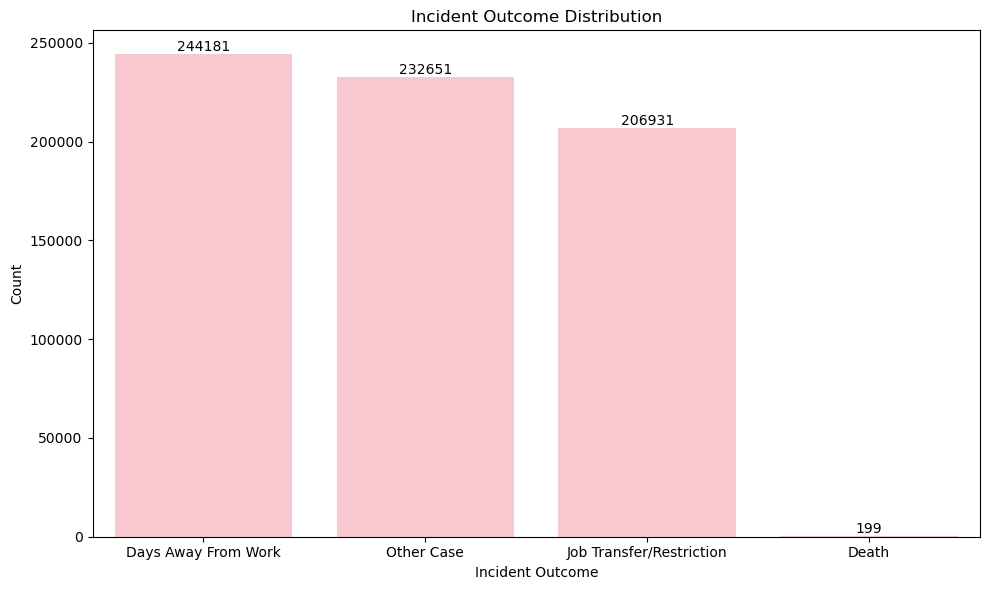

In [20]:
plt.figure(figsize=(10,6))
ax = sns.countplot(x='incident_outcome', data=df, color='pink')

# Add counts on bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom') # this is for the value count for each incident outcomes show in plot

plt.title('Incident Outcome Distribution')
plt.xlabel('Incident Outcome')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

**Interpretation of Incident Outcome Distribution**

The bar chart shows the distribution of workplace incident outcomes in the dataset. The majority of incidents fall into the Days Away From Work (DAFW) category with 244,181 cases, indicating that many workplace accidents result in employees needing time off to recover.

The Other Recordable Case category is the second most common with 232,651 cases, followed by Job Transfer or Restriction with 206,931 cases, where employees were able to work but required modified duties or were transferred to different roles.

In contrast, Death cases are extremely rare, with only 199 incidents, representing a very small proportion of the dataset.

Overall, the distribution suggests that while workplace incidents are relatively frequent, most are non-fatal and involve temporary work absence or job adjustments rather than fatalities. Additionally, the large difference between death cases and other outcomes indicates a strong class imbalance in the dataset.

### Numerical Variables Distribution

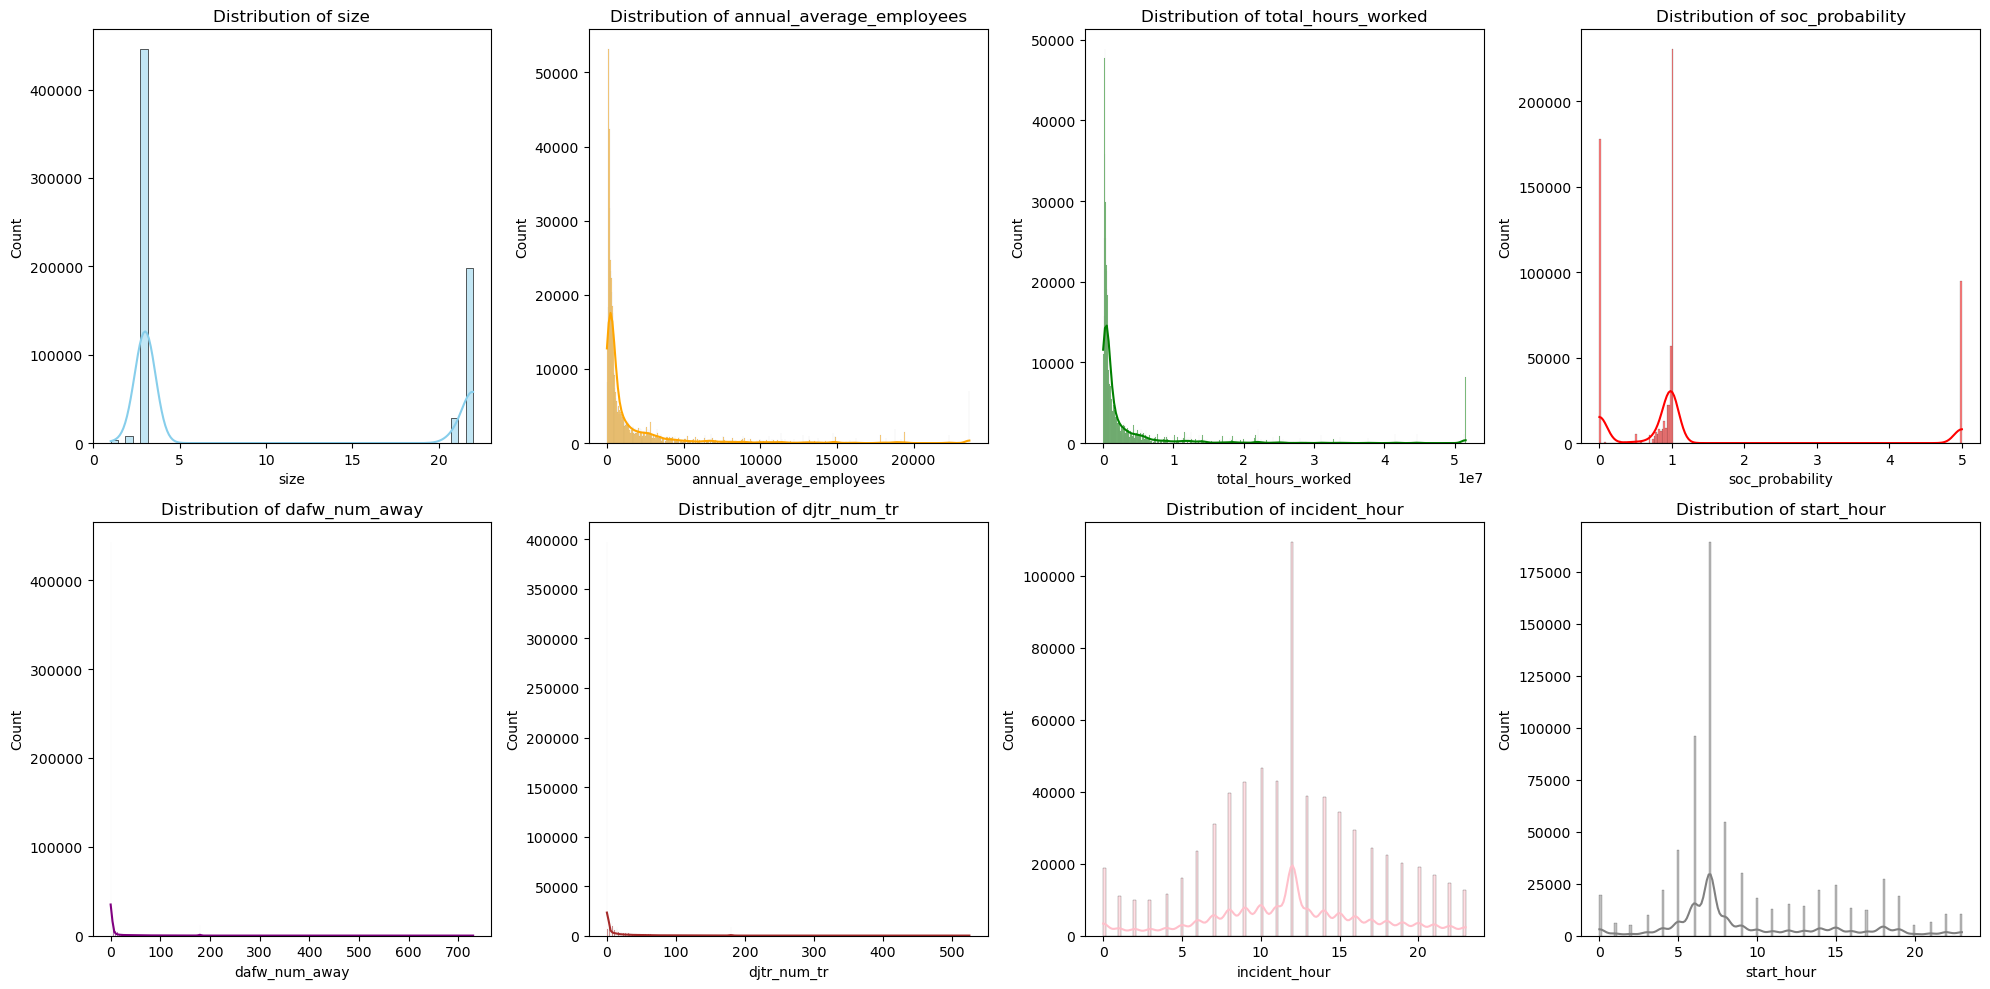

In [21]:
num_cols = [
'size',
'annual_average_employees',
'total_hours_worked',
'soc_probability',
'dafw_num_away',
'djtr_num_tr',
'incident_hour',
'start_hour',
]

fig, axes = plt.subplots(2, 4, figsize=(20,10))

axes = axes.flatten()

colors = ['skyblue','orange','green','red','purple','brown','pink','gray']

for i, col in enumerate(num_cols): # # enumerate() is a Python function that loops through items while also giving their index (position) at the same time
    sns.histplot(df[col], kde=True, ax=axes[i], color=colors[i])
    axes[i].set_title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

In [22]:
skewness = df[num_cols].skew().sort_values(ascending=False)
print(skewness)

total_hours_worked          4.562368
annual_average_employees    3.760814
dafw_num_away               3.638847
djtr_num_tr                 3.090792
soc_probability             1.775352
start_hour                  0.934521
size                        0.716798
incident_hour              -0.057910
dtype: float64


**Interpretation (Univariate Numerical Analysis)**

* size: Most incidents occur in establishments with specific size categories, showing clustered values.
* annual_average_employees: Highly right-skewed; most establishments have fewer employees while a few have extremely large workforce sizes (outliers).
* total_hours_worked: Also right-skewed with some very large values, indicating possible extreme cases.
* soc_probability: Concentrated around a few values (mainly near 1 and 5), showing coding confidence levels.
* dafw_num_away: Most cases have 0 days away from work, meaning many incidents are minor.
* djtr_num_tr: Similar pattern, with most values at 0, indicating few job transfer/restriction cases.
* incident_hour: Incidents are more frequent around midday working hours.
* start_hour: Most employees start work in the early morning (around 6–9 AM).

#### Box Plot for Outlier Detection (Subplots)

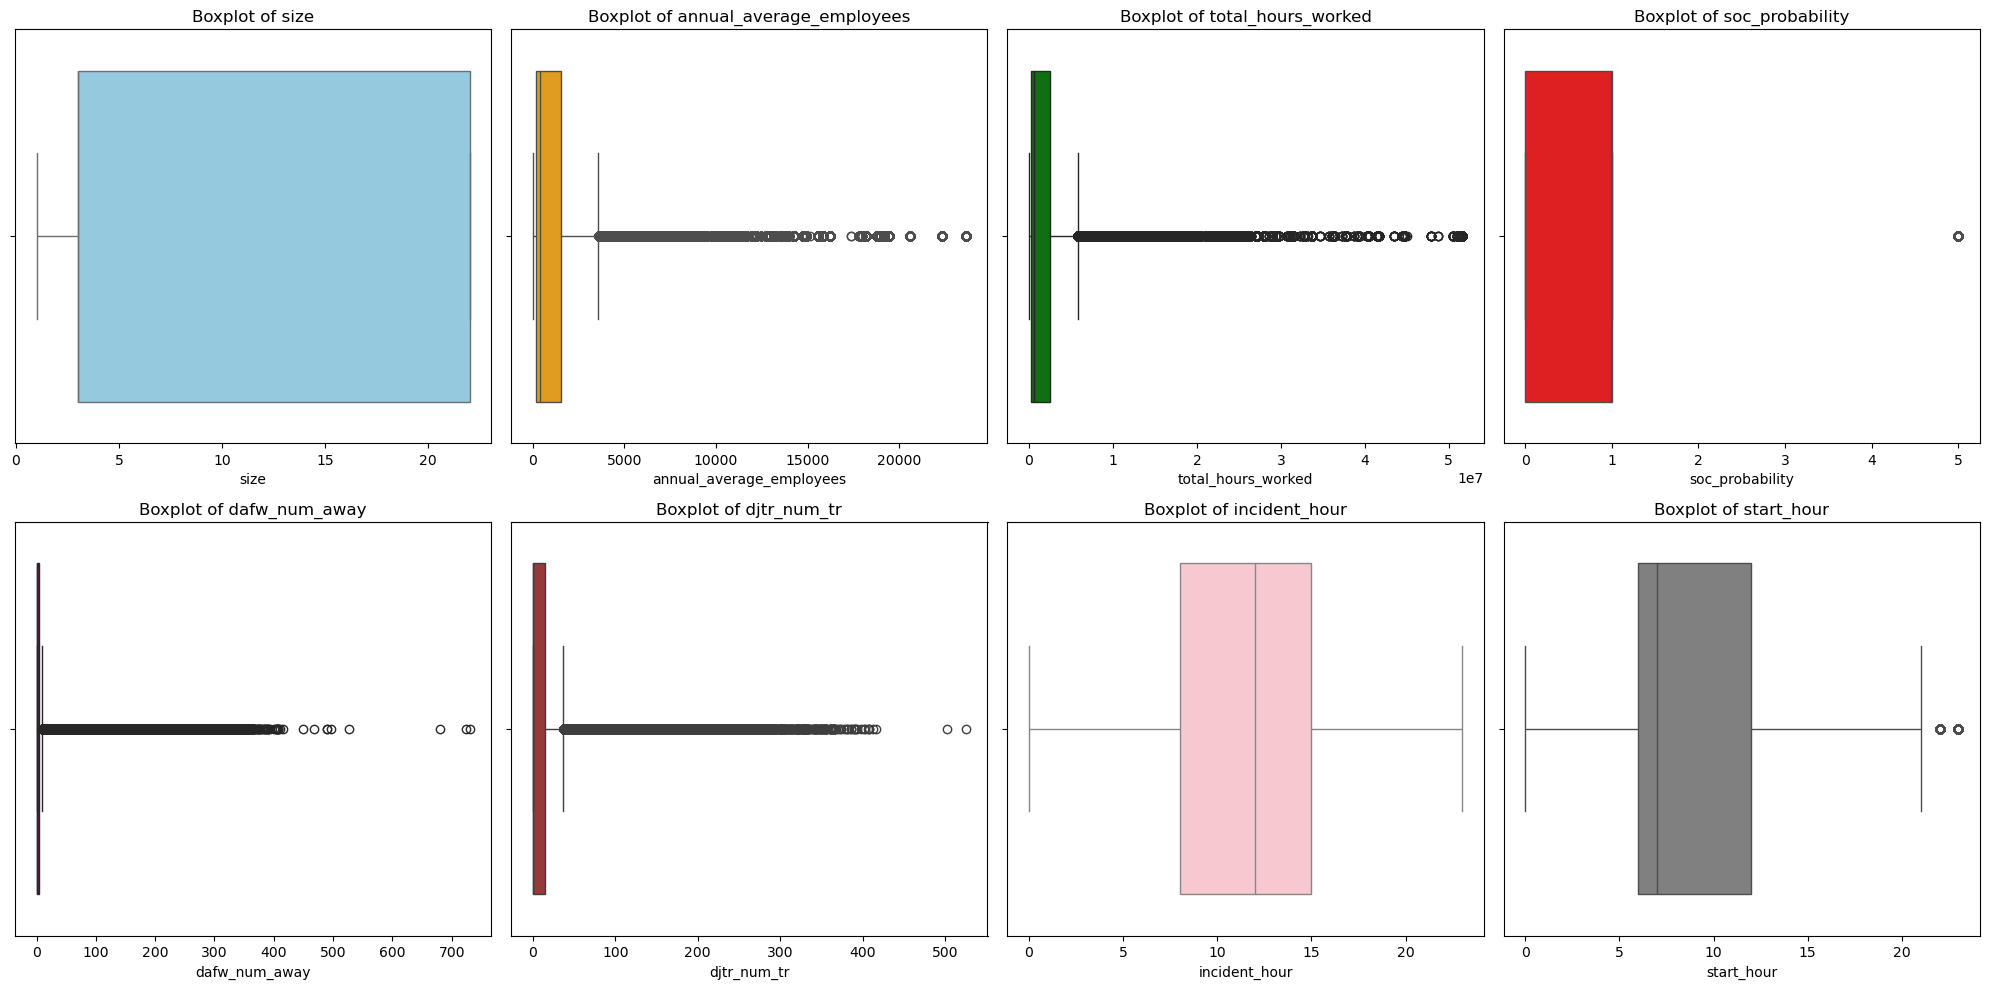

In [23]:
fig, axes = plt.subplots(2, 4, figsize=(20,10))
axes = axes.flatten()

colors = ['skyblue','orange','green','red','purple','brown','pink','gray']

for i, col in enumerate(num_cols): # # enumerate() is a Python function that loops through items while also giving their index (position) at the same time
    sns.boxplot(x=df[col], ax=axes[i], color=colors[i])
    axes[i].set_title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

**Boxplot Interpretation**

* The boxplots help identify extreme values in the numerical variables.
* annual_average_employees and total_hours_worked show significant outliers, with a few establishments reporting extremely large employee counts and working hours compared to the majority.
* dafw_num_away and djtr_num_tr also contain many outliers, indicating that while most incidents involve few or no days away or job restrictions, some cases require long recovery or restriction periods.
* soc_probability shows very few outliers since the values are limited within a small range.
* size, incident_hour, and start_hour remain mostly within normal ranges with minimal extreme values.
* Overall, the presence of outliers in several variables suggests high variability in workplace size, working hours, and injury severity, which should be considered during further analysis or modeling.

### Univariate Analysis for Categorical Variables

#### 1.  Check Unique Values

In [24]:
for col in df.select_dtypes(include='object').columns:
    print(col, ":", df[col].nunique())

establishment_name : 63264
company_name : 23565
street_address : 62218
city : 11900
state : 58
zip_code : 16842
naics_code : 811
naics_year : 3
industry_description : 5325
establishment_type : 3
job_description : 67810
soc_code : 627
soc_description : 627
soc_reviewed : 3
incident_outcome : 4
type_of_incident : 6
time_unknown : 2
NEW_NAR_WHAT_HAPPENED : 642432
NEW_NAR_BEFORE_INCIDENT : 432744
NEW_INCIDENT_LOCATION : 228575
NEW_NAR_INJURY_ILLNESS : 305011
NEW_NAR_OBJECT_SUBSTANCE : 178727
NEW_INCIDENT_DESCRIPTION : 576879
size_category : 3
industry_sector : 23
soc_group : 25


#### 1. Low Cardinality Variables (Good for Visualization)

These have few categories, so we can plot full distributions.

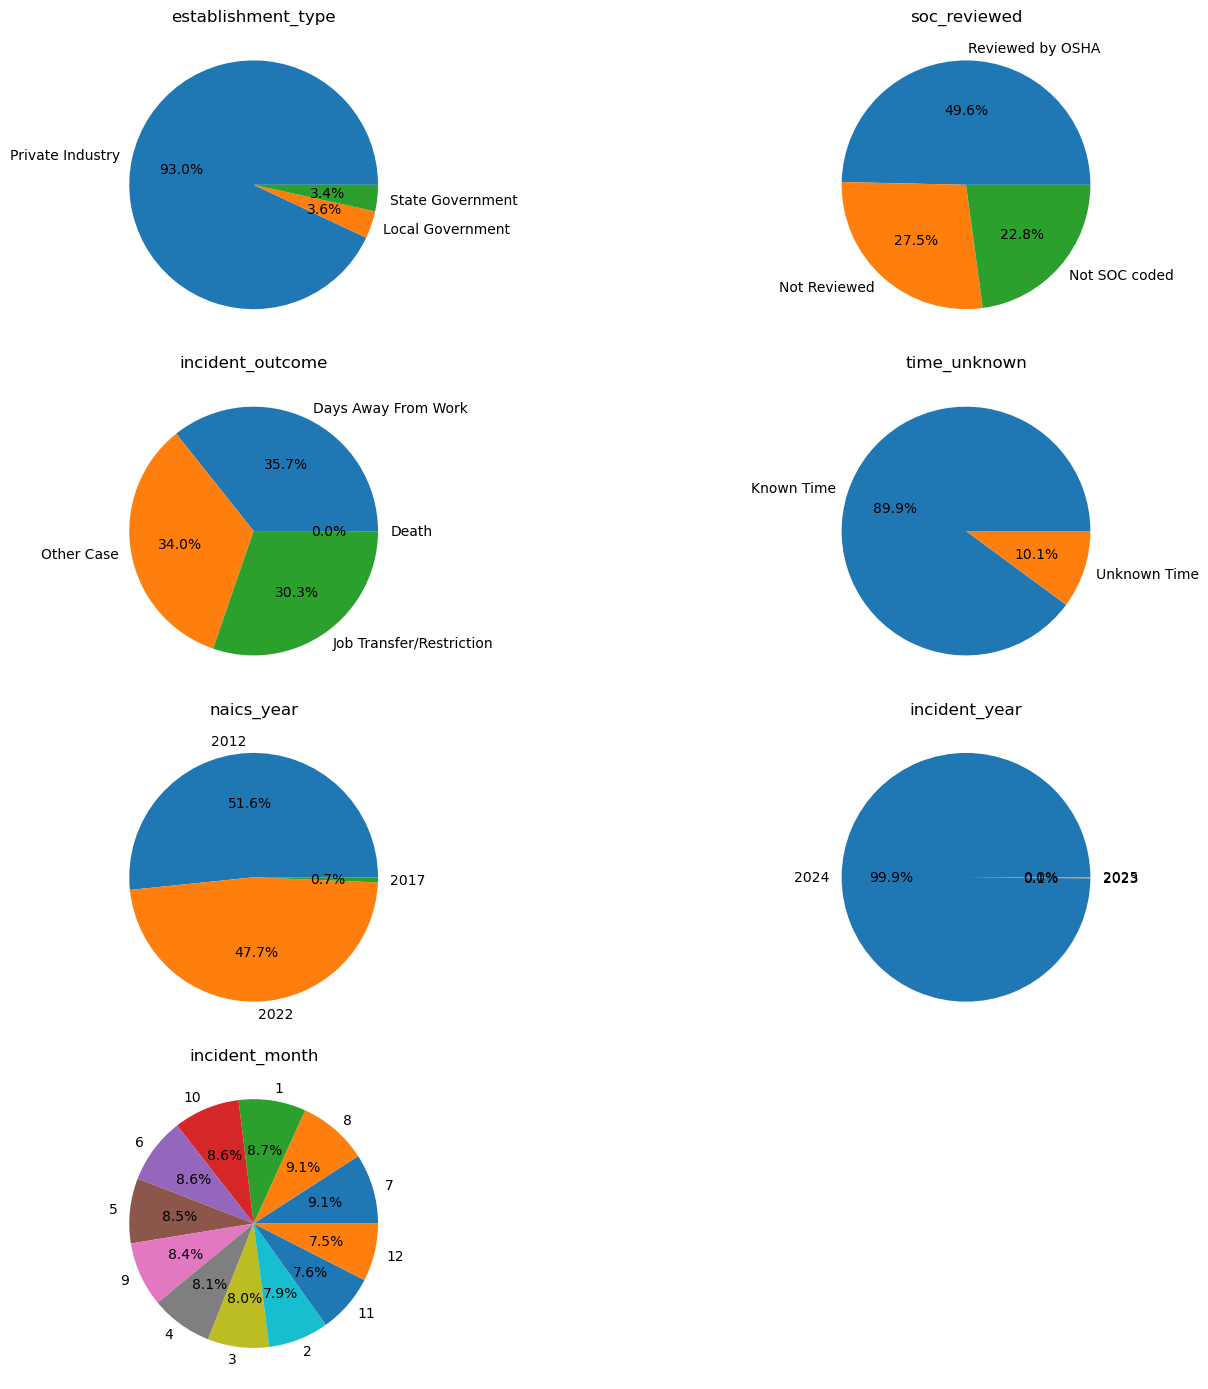

In [25]:
low_cat = [
'establishment_type',
'soc_reviewed',
'incident_outcome',
'time_unknown',
'naics_year',
'incident_year',
'incident_month'
]

plt.figure(figsize=(16,14))

for i, col in enumerate(low_cat): # enumerate() is a Python function that loops through items while also giving their index (position) at the same time
    
    plt.subplot(4,2,i+1)
    
    df[col].value_counts().plot(
        kind='pie',
        autopct='%1.1f%%'
    )
    
    plt.title(col)
    plt.ylabel('')

plt.tight_layout()
plt.show()

**Interpretation*

* Most incidents occur in Private Industry (≈93%), indicating workplace injuries are mainly concentrated in the private sector.
* Nearly half of the cases (≈49.6%) were reviewed by OSHA, while some cases remain unreviewed or not SOC coded.
* The most common incident outcomes are Days Away From Work (≈35.7%), followed by Other Case (≈34%) and Job Transfer/Restriction (≈30.3%), while death cases are extremely rare.
* About 89.9% of incidents have known time information, which allows accurate time-based analysis.
* Industry classification mostly follows NAICS 2012 (≈51.6%) and NAICS 2022 (≈47.7%), with very few records using NAICS 2017.
* Almost all incidents occurred in 2024, indicating the dataset mainly represents that year.
* Incidents are fairly evenly distributed across months, suggesting accidents occur consistently throughout the year.

#### Types of Accident

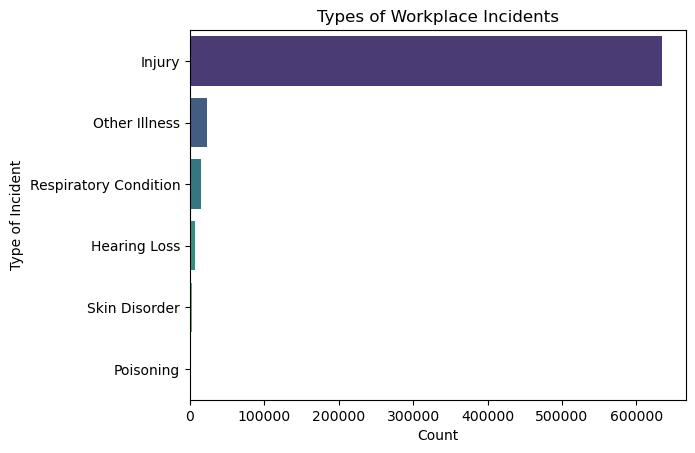

In [26]:
sns.countplot(
    y='type_of_incident',
    data=df,
    order=df['type_of_incident'].value_counts().index,
    palette='viridis'
)

plt.title("Types of Workplace Incidents")
plt.xlabel("Count")
plt.ylabel("Type of Incident")

plt.show()

**Interpretation:-**

* The majority of workplace incidents are Injury cases, which dominate the dataset by a very large margin.
* Other Illness and Respiratory Conditions occur far less frequently compared to injuries.
* Hearing Loss, Skin Disorders, and Poisoning represent only a very small portion of reported incidents.
* Overall, the results indicate that physical injuries are the most common type of workplace incident in the dataset, while illness-related incidents occur relatively rarely.

#### 2️. Medium Cardinality Variables (Top 10 Categories)
These have many categories but still useful insights.

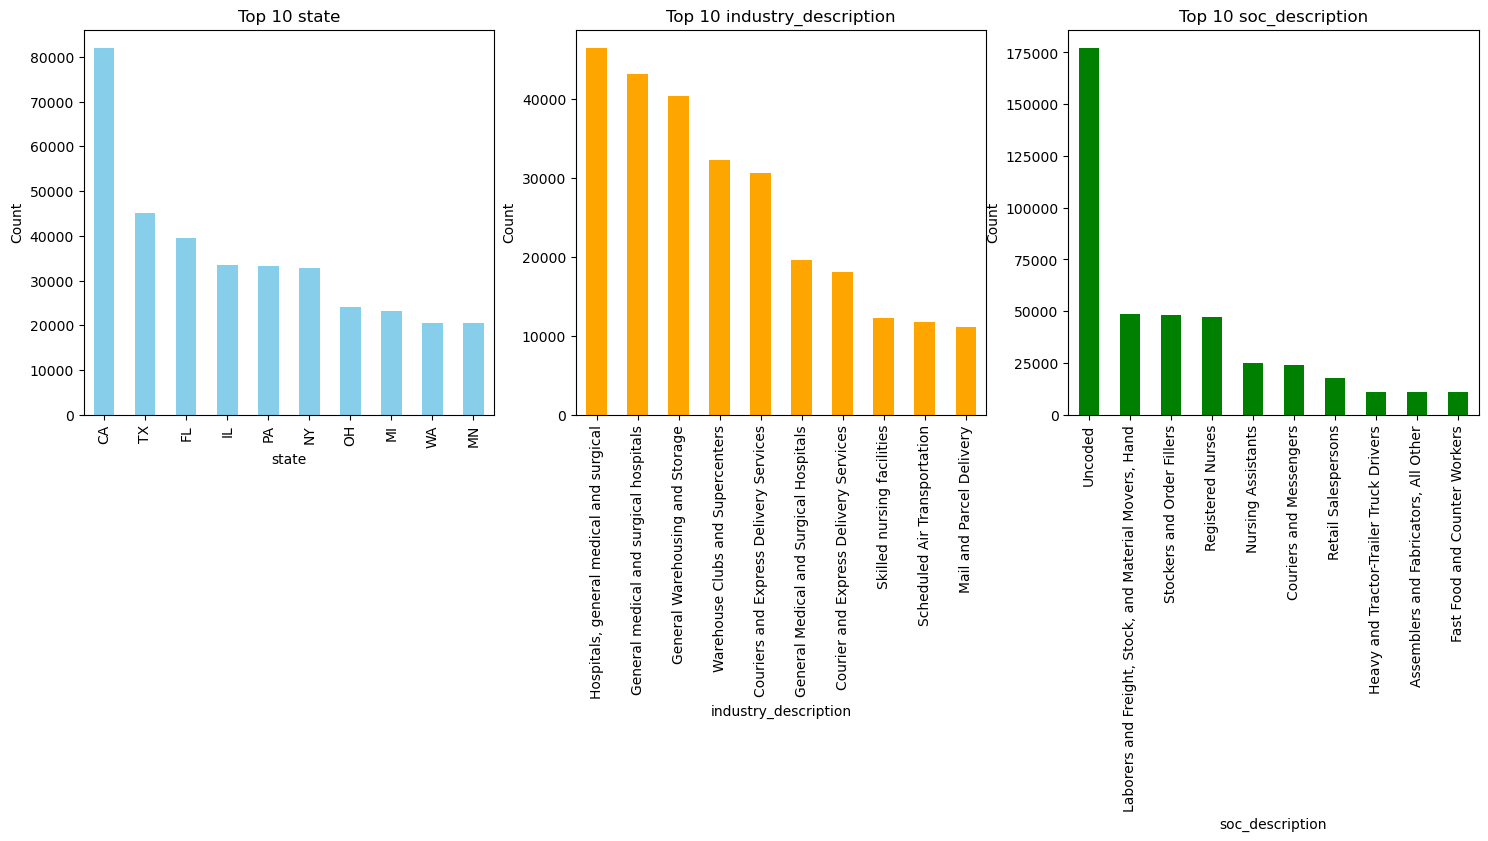

In [27]:
medium_cat = [
'state',
'industry_description',
'soc_description'
]

fig, axes = plt.subplots(1,3, figsize=(18,5))

colors = ['skyblue','orange','green']

for i, col in enumerate(medium_cat): # # enumerate() is a Python function that loops through items while also giving their index (position) at the same time
    df[col].value_counts().head(10).plot(
        kind='bar',
        ax=axes[i],
        color=colors[i]
    )
    axes[i].set_title(f'Top 10 {col}')
    axes[i].set_ylabel("Count")
    axes[i].tick_params(axis='x', rotation=90)

# plt.tight_layout()
plt.show()

**Interpretation of Top Categories**
* Top States: California reports the highest number of workplace incidents, followed by Texas and Florida. Other states such as Illinois, Pennsylvania, and New York also show significant counts, indicating that incidents are concentrated in large and industrially active states.
* Top Industries: The highest number of incidents occur in Hospitals (general medical and surgical), followed by general medical and surgical hospitals and general warehousing and storage. Industries related to transportation, delivery services, and healthcare also appear frequently, suggesting higher exposure to workplace risks in these sectors.
* Top Occupations (SOC Description): The largest category is Uncoded occupations, indicating that many records do not have a specific occupational classification. Among coded occupations, laborers and freight handlers, stockers and order fillers, and registered nurses appear most frequently, highlighting jobs involving physical labor and healthcare services as more prone to workplace incidents.

## Bivariate Analysis

### Target Variable with Categorical

#### 1. Incident Outcome vs Type of Incident
This shows which incident types cause severe outcomes.

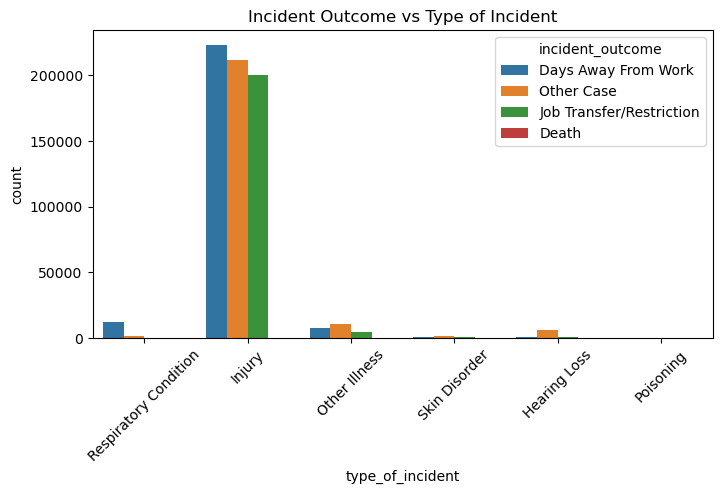

In [28]:
plt.figure(figsize=(8,4))

sns.countplot(x='type_of_incident',
              hue='incident_outcome',
              data=df)

plt.title("Incident Outcome vs Type of Incident")
plt.xticks(rotation=45)
plt.show()

**Interpretation: Incident Outcome vs Type of Incident**

* The plot shows the relationship between type of incident and the resulting incident outcome.
* Injury is the most common type of incident and accounts for the majority of all outcomes, including Days Away From Work, Other Cases, and Job Transfer/Restriction.
* Respiratory conditions also lead to a noticeable number of cases requiring days away from work, though they occur far less frequently than injuries.
* Other illnesses result in moderate numbers of cases, mainly leading to other recordable cases and job transfer or restriction.
* Skin disorders, hearing loss, and poisoning occur relatively rarely compared to injuries.
* Death cases are extremely low across all incident types, indicating that most workplace incidents are non-fatal.
* Overall, the analysis shows that physical injuries dominate workplace incidents and are the primary cause of serious outcomes such as days away from work or job restrictions.

#### 2. Incident Outcome vs Establishment Type
Shows whether private industry or government workplaces experience more severe incidents.

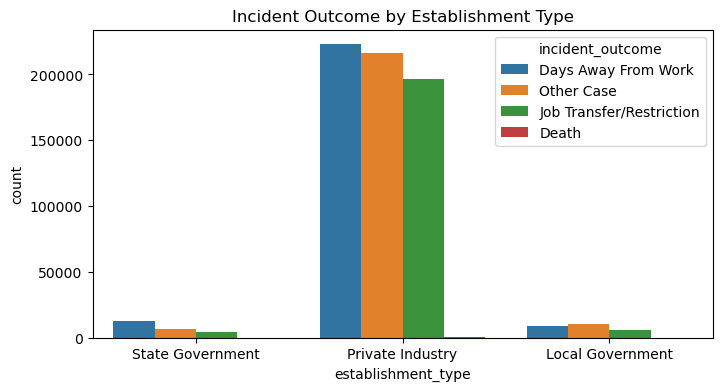

In [29]:
plt.figure(figsize=(8,4))

sns.countplot(x='establishment_type',
              hue='incident_outcome',
              data=df)

plt.title("Incident Outcome by Establishment Type")
plt.show()

**Interpretation: Incident Outcome by Establishment Type**

* The plot shows how incident outcomes vary across different establishment types.
* Private Industry accounts for the vast majority of workplace incidents across all outcome categories, including days away from work, other recordable cases, and job transfer or restriction.
* State Government and Local Government establishments report significantly fewer incidents compared to private industries.
* Among all establishment types, Days Away From Work is the most common outcome, indicating that many incidents result in employees needing time off for recovery.
* Death cases remain extremely rare across all establishment types.
* Overall, the analysis indicates that private industry workplaces experience the highest number of workplace incidents, likely due to larger workforce sizes and higher exposure to occupational risks.

#### 3. Incident Outcome vs State (Top 10)
Helps identify states with the most severe workplace incidents.

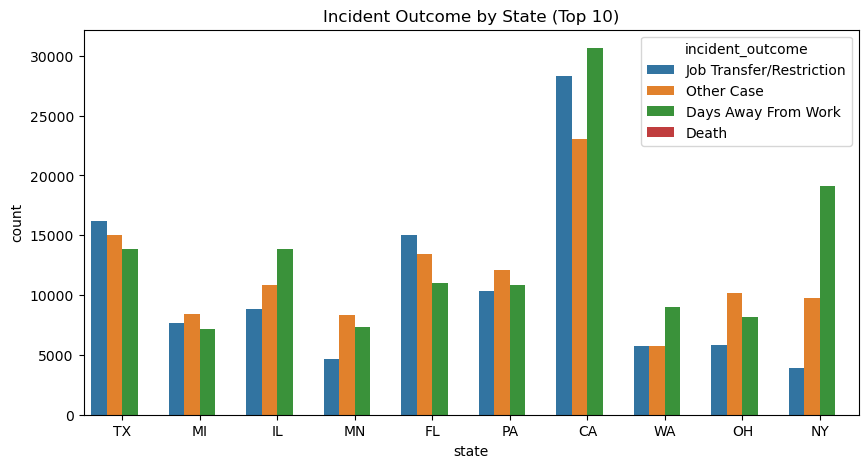

In [30]:
top_states = df['state'].value_counts().head(10).index

plt.figure(figsize=(10,5))

sns.countplot(x='state',
              hue='incident_outcome',
              data=df[df['state'].isin(top_states)])

plt.title("Incident Outcome by State (Top 10)")
plt.show()

**Interpretation: Incident Outcome by State (Top 10)**
* The chart shows how workplace incident outcomes are distributed across the top 10 states with the highest number of incidents.
* California (CA) reports the highest number of incidents across all outcome categories, especially Days Away From Work, indicating a high level of workplace activity and exposure to occupational risks.
* Texas (TX) and New York (NY) also show significant numbers of incidents, particularly cases resulting in days away from work.
* States such as Florida (FL), Pennsylvania (PA), and Illinois (IL) have moderate incident counts across different outcome categories.
* Job Transfer/Restriction and Other Cases occur frequently in most states, indicating that many injuries require work adjustments rather than complete absence.
* Death cases remain extremely low across all states, suggesting that most workplace incidents are non-fatal.
* Overall, the analysis indicates that large and highly industrialized states tend to report higher numbers of workplace incidents, likely due to larger workforces and more active industries.

#### 4. Incident Outcome vs Industry(top 10)
Shows which industries experience the most severe incidents.

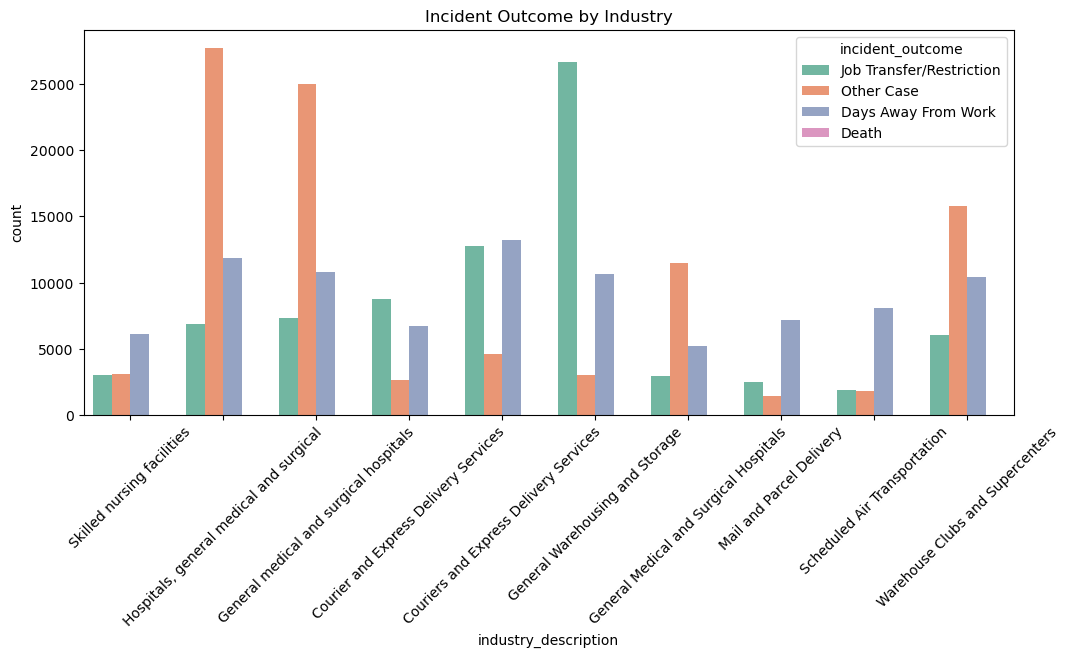

In [31]:
top_ind = df['industry_description'].value_counts().head(10).index

plt.figure(figsize=(12,5))

sns.countplot(
    x='industry_description',
    hue='incident_outcome',
    data=df[df['industry_description'].isin(top_ind)],
    palette='Set2'   # 🎨 color added
)

plt.xticks(rotation=45)
plt.title("Incident Outcome by Industry")
plt.show()

**Interpretation: Incident Outcome by Industry**
* The chart shows how workplace incident outcomes vary across the top industries with the highest number of incidents.
* Hospitals and healthcare-related industries report a large number of incidents, particularly cases resulting in other recordable cases and days away from work, indicating frequent workplace injuries in healthcare environments.
* Courier, delivery services, and warehousing industries also show high incident counts, especially job transfer/restriction and days away from work, likely due to physically demanding tasks and transportation-related risks.
* General warehousing and storage has a particularly high number of job transfer or restriction cases, suggesting injuries that require modified duties rather than complete absence from work.
* Transportation industries such as scheduled air transportation and mail or parcel delivery also report moderate incident levels.
* Death cases remain extremely low across all industries, indicating that while injuries occur frequently, most incidents are non-fatal.
* Overall, the analysis suggests that healthcare, logistics, and warehousing industries experience the highest number of workplace incidents, likely due to the nature of their work involving physical activity, patient handling, and transportation operations.

#### 5. Incident Month vs Incident Outcome
This checks if certain months have more severe incidents.

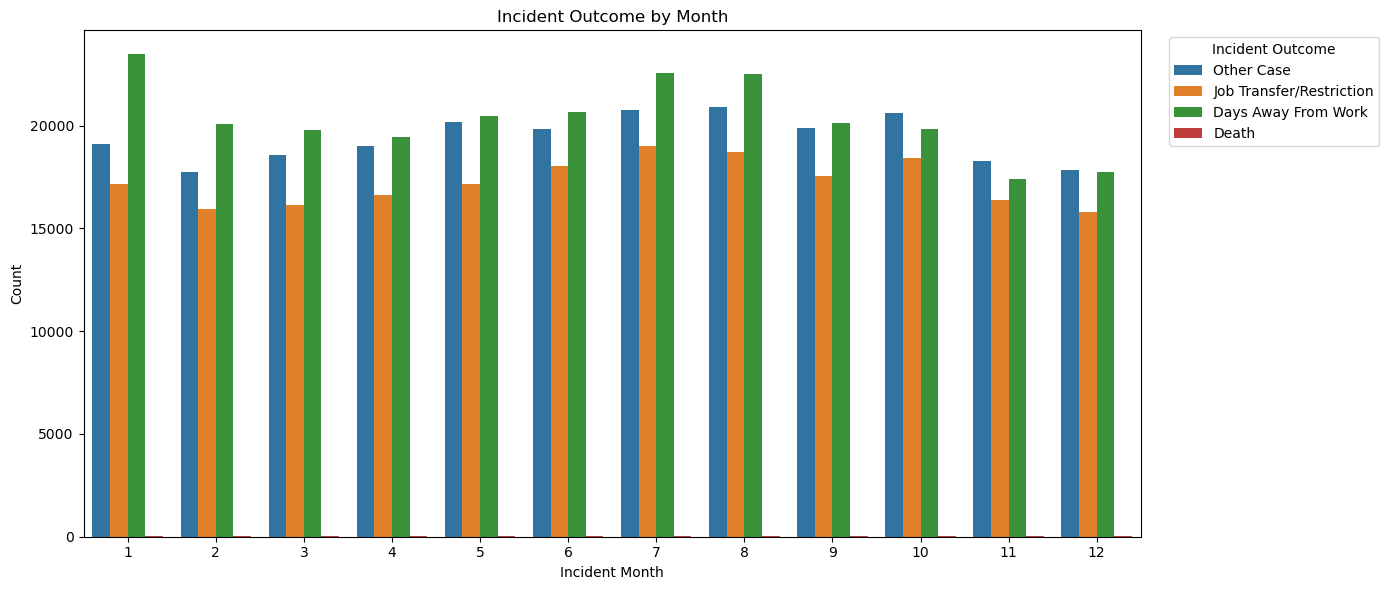

In [32]:
plt.figure(figsize=(14,6))

sns.countplot(
    x='incident_month',
    hue='incident_outcome',
    data=df
)

plt.title("Incident Outcome by Month")
plt.xlabel("Incident Month")
plt.ylabel("Count")

plt.xticks(rotation=0)
plt.legend(title='Incident Outcome', bbox_to_anchor=(1.02,1), loc='upper left')

plt.tight_layout()
plt.show()

**Interpretation: Incident Outcome by Month**
* The chart shows how workplace incident outcomes vary across different months of the year.
* Incidents occur consistently throughout the year, with no extremely sharp spikes in any specific month.
* Days Away From Work remains the most common outcome across all months, indicating that many incidents result in employees needing time off to recover.
* Other Cases and Job Transfer/Restriction are also frequent outcomes, though slightly lower than days away from work.
* The number of incidents appears to increase slightly during the middle months of the year (around June to August), which may correspond to periods of higher workplace activity.
* Death cases remain extremely rare a
* cross all months, showing that most workplace incidents are non-fatal.
* Overall, the distribution suggests that workplace incidents are fairly evenly spread across the year, with a slight rise during peak working months.

#### Target vs Shift

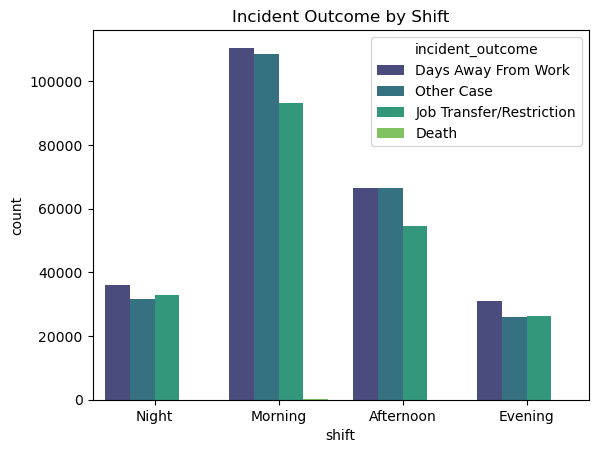

In [33]:
sns.countplot(
    x='shift',
    hue='incident_outcome',
    data=df,
    palette='viridis'
)

plt.title("Incident Outcome by Shift")
plt.show()

**Interpretation**
* The chart shows how different types of incident outcomes are distributed across work shifts.
* It is observed that the majority of incidents occur during the morning shift, followed by the afternoon shift. This is likely due to higher workforce activity and operational intensity during these hours.
* The night and evening shifts show comparatively fewer incidents, which may be attributed to reduced workforce size or lower operational activity.
* Across all shifts, "Days Away From Work" and "Other Cases" are the most common outcomes, indicating that most incidents are non-fatal but still impact productivity.
* Although rare, fatal incidents (death) appear very minimal across all shifts, suggesting that severe incidents are less frequent but still critical.
* Overall, shift timing plays an important role in incident occurrence, with peak incidents aligning with peak working hours.

#### Target vs Season

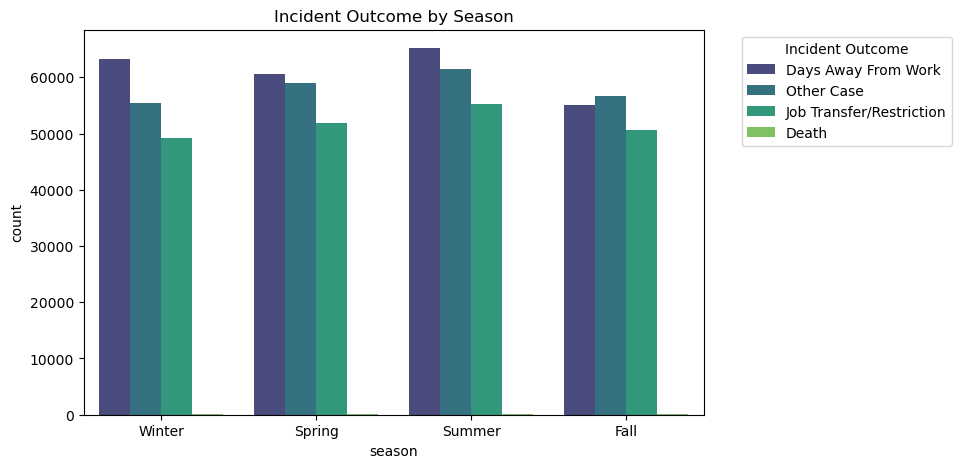

In [34]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='season',
    hue='incident_outcome',
    data=df,
    palette='viridis'
)

plt.title("Incident Outcome by Season")

plt.legend(title='Incident Outcome', bbox_to_anchor=(1.05,1), loc='upper left')

plt.show()

**Interpretation:**
* Summer shows the highest number of incidents across all outcome categories compared to other seasons.
* Days Away From Work is the most common outcome in every season, indicating injuries often require employees to take time off.
* Other Case and Job Transfer/Restriction also occur frequently, while death cases are extremely rare across all seasons.
* Overall, workplace incidents occur throughout the year, but slightly increase during the summer season.

### Numerical Variable vs Target Variable


#### 1. Employees vs Outcome

Shows whether larger workplaces experience more severe incidents.

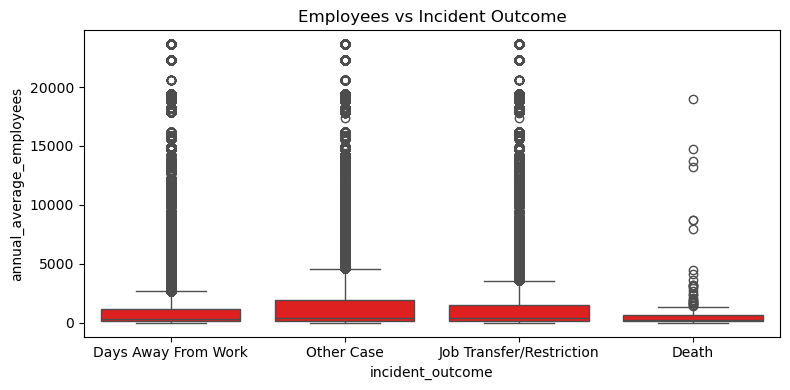

In [35]:
plt.figure(figsize=(8,4))

sns.boxplot(x='incident_outcome',
            y='annual_average_employees', color='red',
            data=df)

plt.title("Employees vs Incident Outcome")
plt.tight_layout()
plt.show()

**Interpretation: Employees vs Incident Outcome**
* The boxplot shows the relationship between the number of employees in an establishment and the type of incident outcome.
* Most incidents occur in establishments with relatively small to medium employee sizes, as indicated by the concentration of values near the lower range.
* All outcome categories show many outliers, meaning some incidents occur in establishments with very large numbers of employees.
* The Other Case category appears to have slightly higher median employee counts compared to other outcomes.
* Death cases occur across establishments of varying sizes, though the number of such cases is very small.
* Overall, the plot suggests that workplace incidents occur across establishments of different sizes, but extreme employee counts create noticeable outliers in the distribution.

#### 2. Days Away From Work vs Incident Outcome

Shows how severity affects recovery time.

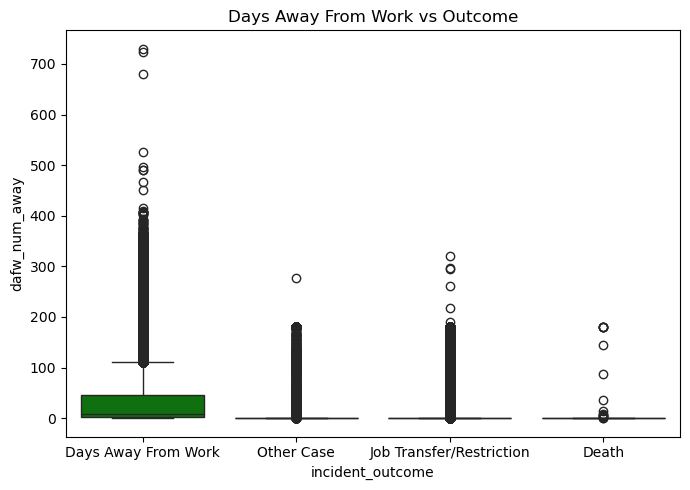

In [36]:
plt.figure(figsize=(7,5))

sns.boxplot(x='incident_outcome',
            y='dafw_num_away', color='green',
            data=df)

plt.title("Days Away From Work vs Outcome")
plt.tight_layout()
plt.show()

**Interpretation: Days Away From Work vs Incident Outcome**

* The boxplot illustrates the relationship between the number of days employees were away from work and the type of incident outcome.
* The Days Away From Work category naturally shows higher values, indicating that these incidents often require employees to take time off for recovery.
* Most cases across all outcomes are concentrated near lower values, meaning many incidents result in few or no days away from work.
* There are several extreme outliers, especially in the Days Away From Work outcome, where some employees required a very long recovery period.
* The Other Case and Job Transfer/Restriction categories mostly show values close to zero, indicating that these incidents often do not require extended time away from work.
* Death cases appear with very small values because these incidents are rare and do not typically involve recorded recovery periods.
* Overall, the distribution shows that while most workplace incidents involve minimal absence from work, some severe injuries can result in significantly longer recovery times.

### 3. Job Transfer Days vs Outcome
Shows how long workers remain on restricted duties.

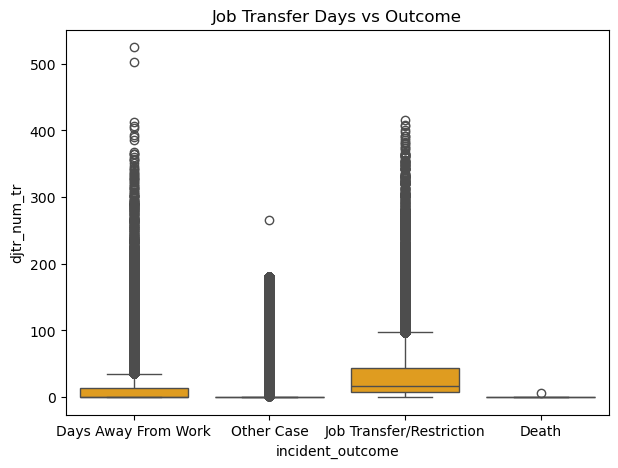

In [37]:
plt.figure(figsize=(7,5))

sns.boxplot(x='incident_outcome',
            y='djtr_num_tr', color='orange',
            data=df)

plt.title("Job Transfer Days vs Outcome")
plt.show()

**Interpretation: Job Transfer Days vs Incident Outcome**
* The boxplot shows the relationship between the number of job transfer or restriction days and the type of incident outcome.
* The Job Transfer/Restriction outcome has the highest number of job transfer days, indicating that employees in this category often require modified duties or temporary reassignment.
* Most values across all categories are concentrated near lower ranges, meaning many incidents do not require long periods of job transfer or restriction.
* The Days Away From Work category shows some transfer days but generally fewer compared to the Job Transfer/Restriction category.
* Other Case incidents mostly show very low or zero transfer days, indicating that these injuries are usually less severe.
* Death cases show almost no job transfer days since these incidents do not involve recovery or reassignment periods.
* Overall, the analysis indicates that job transfer or restriction incidents tend to involve longer periods of modified work, while most other incidents result in minimal or no job reassignment.

### Categorical VS Categorical (Without target variable)

#### 1. Type of Incident vs Establishment Type
Shows which workplaces experience different types of incidents.

Helps identify whether private industries or government sectors face certain incident types more often.

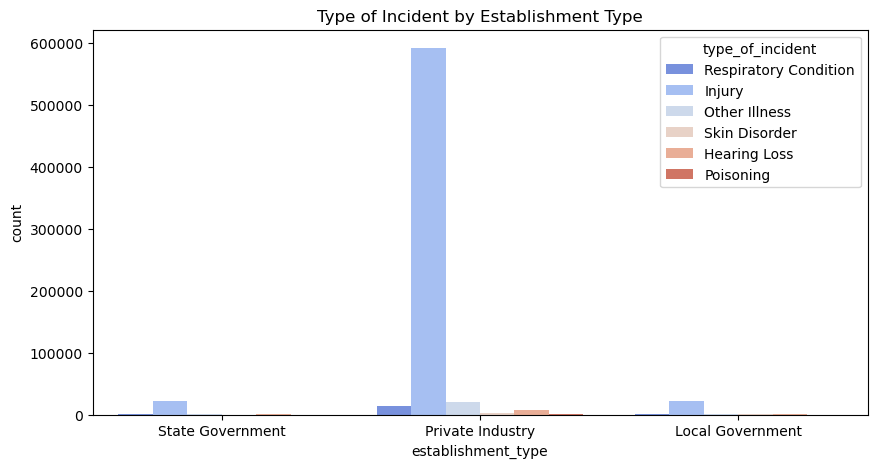

In [38]:
plt.figure(figsize=(10,5))

sns.countplot(x='establishment_type',
              hue='type_of_incident',
              data=df,
              palette='coolwarm'
              )

plt.title("Type of Incident by Establishment Type")
plt.show()

**Interpretation: Type of Incident by Establishment Type**
* The chart illustrates how different types of workplace incidents are distributed across various establishment types.
* Private Industry accounts for the overwhelming majority of incidents across all categories, particularly injuries, which dominate the dataset.
* State Government and Local Government establishments report significantly fewer incidents compared to private industry workplaces.
* Injury is the most common incident type across all establishment types, indicating that physical injuries are the primary workplace safety concern.
* Other incident types such as respiratory conditions, hearing loss, skin disorders, and poisoning occur much less frequently.
* Overall, the analysis suggests that private industry workplaces experience far more incidents than government establishments, likely due to larger workforce sizes and greater exposure to physically demanding or hazardous tasks.

#### 2. Type of Incident vs Industry
Shows which industries experience specific types of injuries.

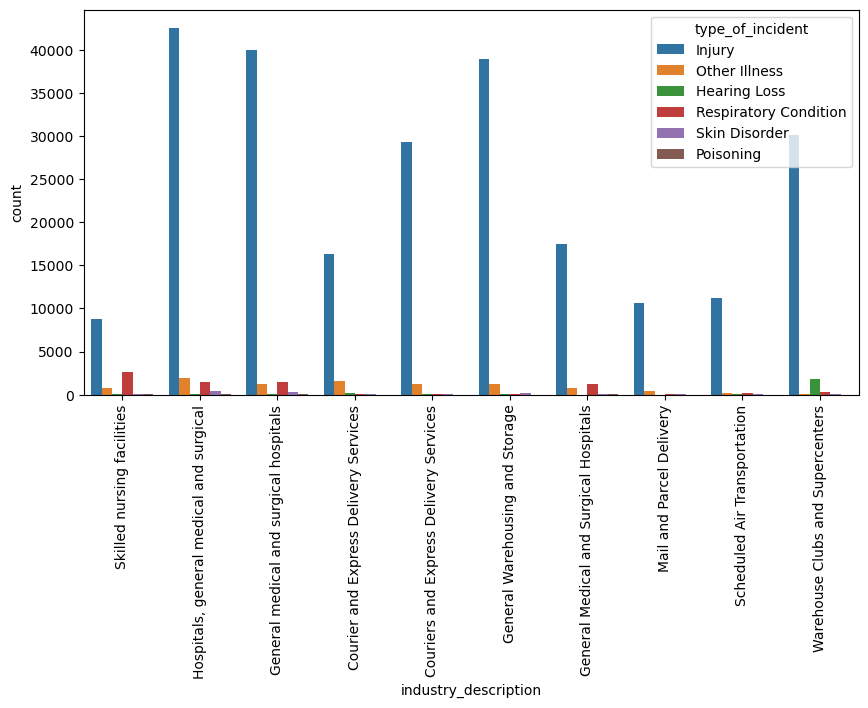

In [39]:
top_ind = df['industry_description'].value_counts().head(10).index

plt.figure(figsize=(10,5))

sns.countplot(x='industry_description',
              hue='type_of_incident',
              data=df[df['industry_description'].isin(top_ind)],
              palette='tab10'
             )

plt.xticks(rotation=90)

plt.show()

**Interpretation: Type of Incident by Industry**
* The chart shows how different types of workplace incidents are distributed across the top industries.
* Injury is the most dominant incident type across all industries, indicating that physical injuries are the primary workplace safety issue.
* Hospitals (general medical and surgical) and general medical and surgical hospitals report the highest number of injuries, likely due to activities such as patient handling, medical procedures, and high workforce interaction.
* Warehousing, courier, and delivery services also show a large number of injury cases, which may be related to heavy lifting, transportation tasks, and physically demanding work environments.
* Respiratory conditions and other illnesses appear in smaller numbers across industries, suggesting they occur less frequently compared to injuries.
* Hearing loss, skin disorders, and poisoning are relatively rare across all industries.
* Overall, the analysis indicates that healthcare, logistics, and warehousing industries experience the highest number of injury-related incidents, highlighting the need for stronger safety measures in physically demanding and high-activity workplaces.

### Multivariate Analysis

#### 1. Correlation Heatmap (Numerical Variables)
This shows the relationship between numerical variables.

<Figure size 2000x1200 with 0 Axes>

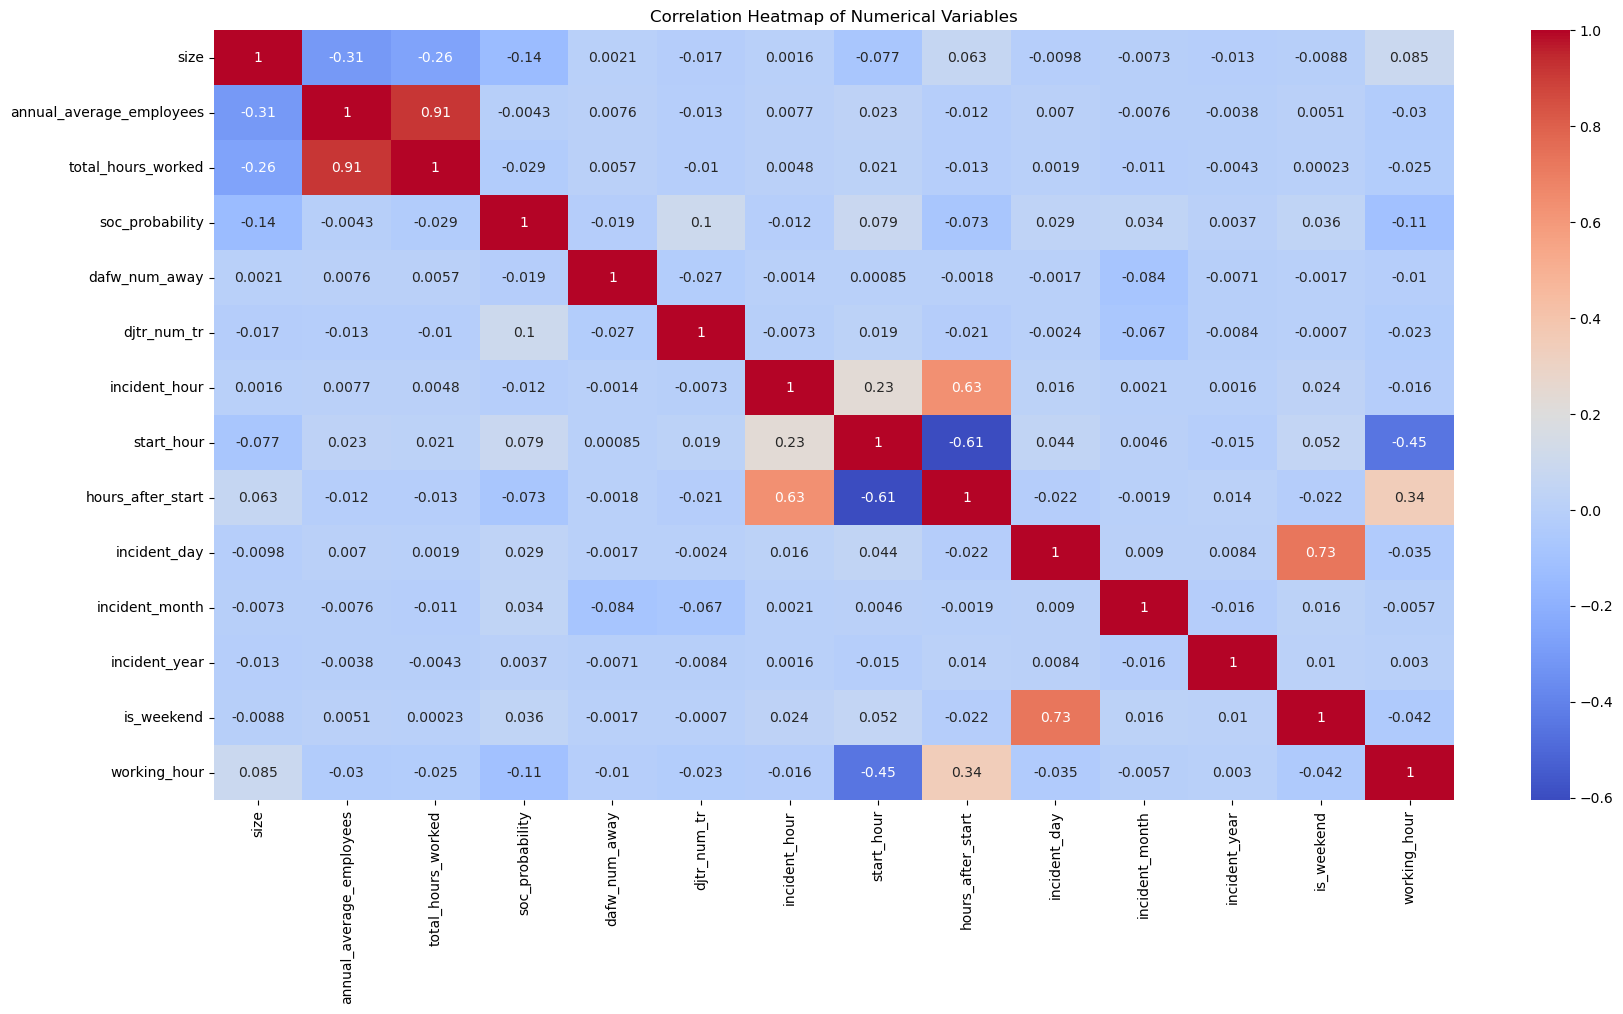

In [40]:
plt.figure(figsize=(20,12))

corr_cols = [
'size',
'annual_average_employees',
'total_hours_worked',
'soc_probability',
'dafw_num_away',
'djtr_num_tr',
'incident_hour',
'start_hour',
'hours_after_start',
'incident_day',
'incident_month',
'incident_year',
'is_weekend',
'working_hour'
]

corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(20,10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap of Numerical Variables")
plt.show()

**Interpretation: Correlation Heatmap of Numerical Variables**
* The heatmap illustrates the correlation between the numerical variables in the dataset.
* Annual average employees and total hours worked show a very strong positive correlation (≈0.91), indicating that establishments with more employees generally report higher total working hours.
* Size has a moderate negative correlation with both annual average employees and total hours worked, suggesting that the size category may not directly reflect the actual number of employees or hours worked.
* Variables related to incident severity, such as days away from work (dafw_num_away) and job transfer/restriction days (djtr_num_tr), show very weak correlations with most other variables, indicating that recovery time is largely independent of establishment size or working hours.
* Incident hour and start hour show a small positive correlation, meaning incidents tend to occur closer to the beginning of work shifts.
* Most other correlations are close to zero, suggesting that many numerical variables in the dataset are largely independent.
* Overall, the analysis indicates that workforce size strongly influences total working hours, while incident severity and timing variables are relatively independent of establishment characteristics.

#### 2. Pairplot (Multiple Numerical Relationships)
Helps visualize how numerical variables interact with incident outcomes.

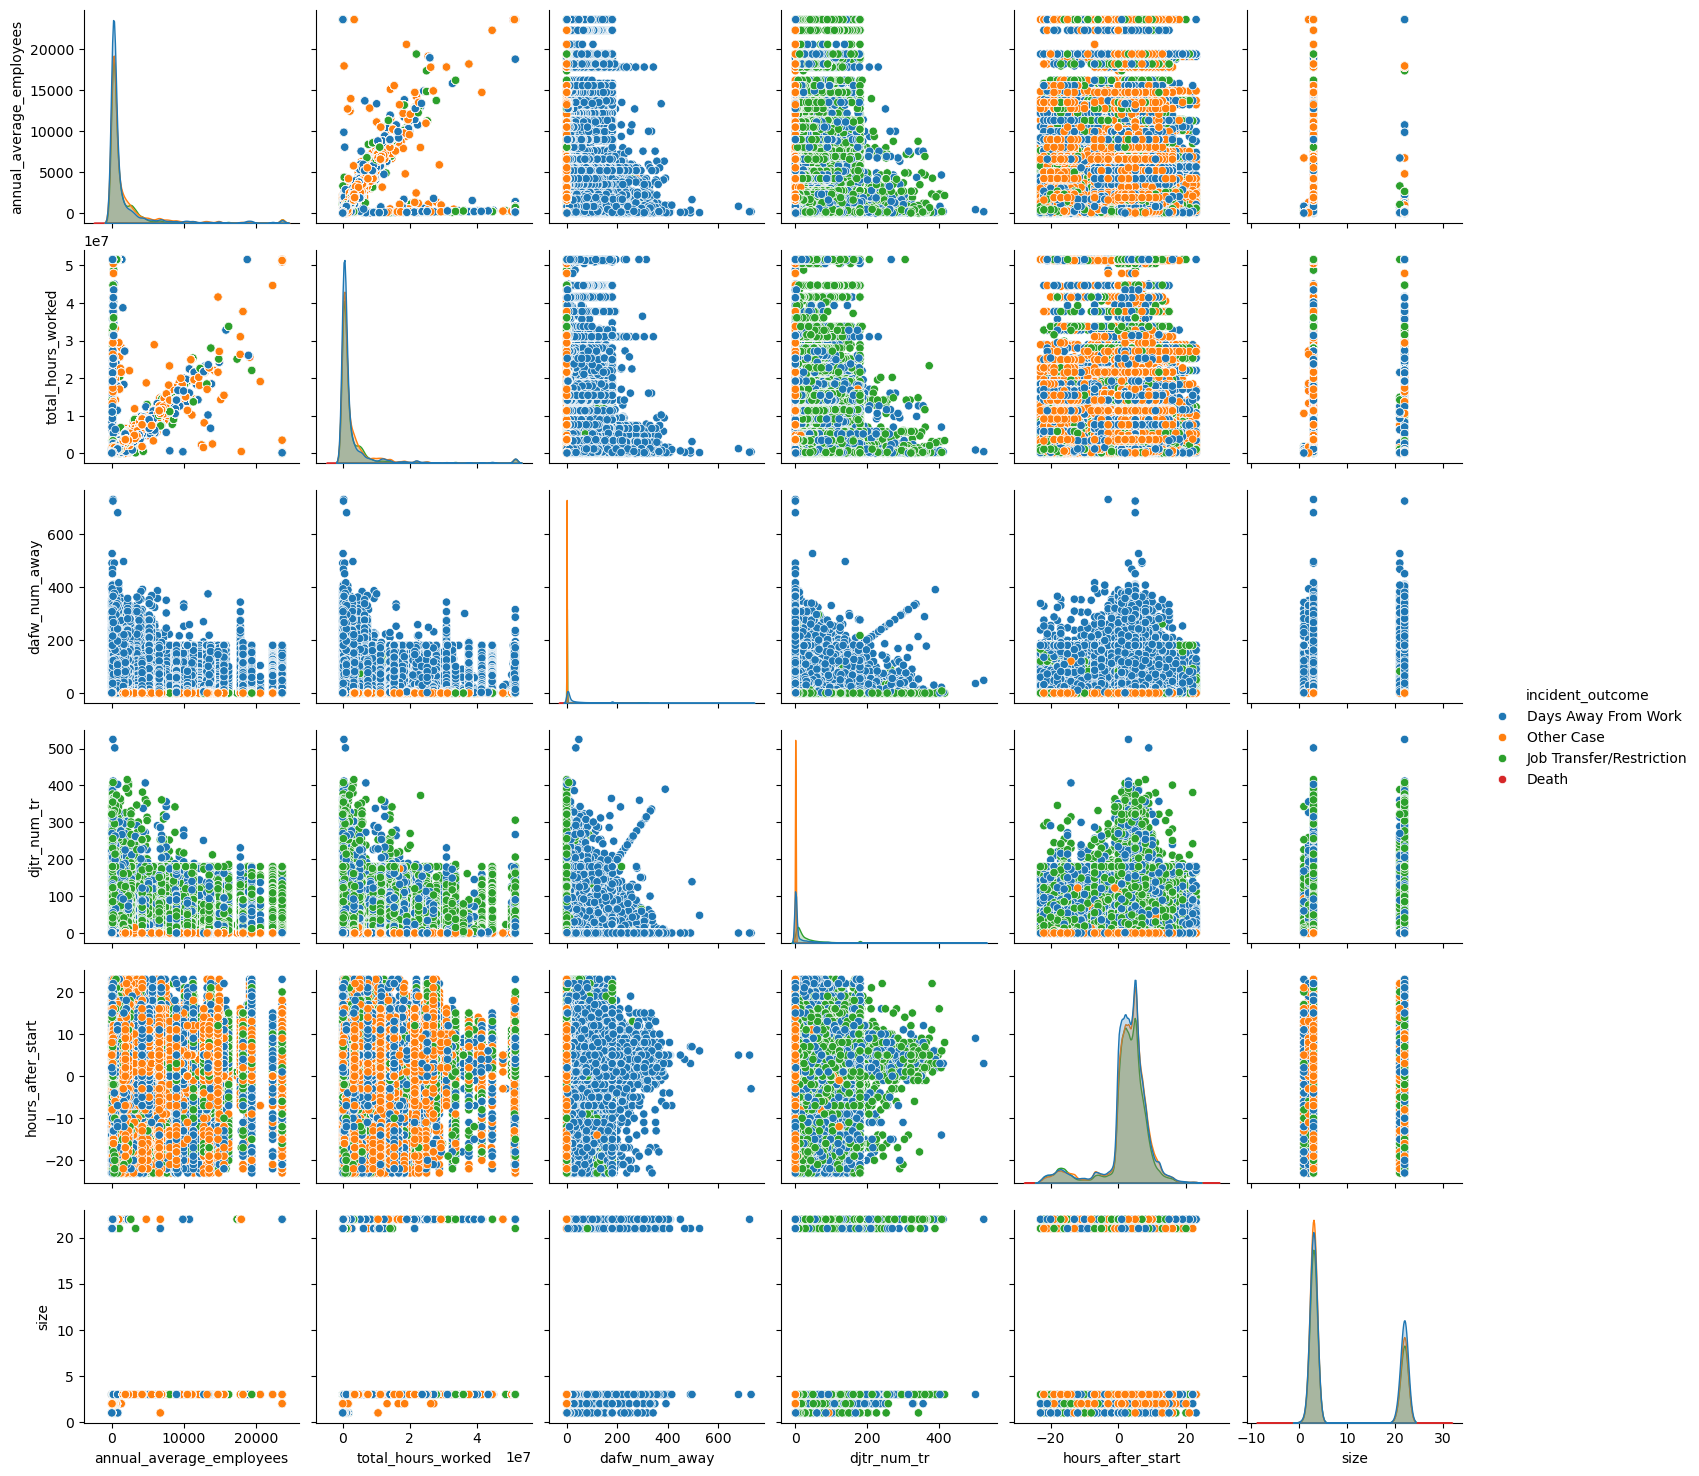

In [41]:
sns.pairplot(
    df[['annual_average_employees',
        'total_hours_worked',
        'dafw_num_away',
        'djtr_num_tr',
        'incident_outcome',
       'hours_after_start',
       'size']],
    hue='incident_outcome'
)

# its take to much time like 4-5 hours thats why we write the interpretation.

**Interpretation of the Pairplot (Multivariate Analysis):**
* Annual Average Employees vs Total Hours Worked shows a positive relationship, meaning organizations with more employees tend to have higher total working hours.
* DAFW (Days Away From Work) and DJTR (Job Transfer/Restriction) appear to have a moderate relationship, indicating that incidents causing days away from work often also involve job restrictions or transfers.
* The distributions of annual_average_employees, total_hours_worked, dafw_num_away, and djtr_num_tr are highly right-skewed, showing that most organizations have lower values while a few have very high values.
* The incident outcome categories overlap heavily, meaning these numerical variables alone do not clearly separate the different outcome types.
* Hours after start and company size do not show a strong visible relationship with the severity indicators, suggesting these variables may have limited influence on incident outcomes.
* Overall, the pairplot suggests that workforce size and working hours are related, while injury severity variables show some correlation but limited separation across outcome categories.

## Objective  – Hazardous Industry Analysis (EDA)

In [42]:
df['incident_outcome'].value_counts()

incident_outcome
Days Away From Work         244181
Other Case                  232651
Job Transfer/Restriction    206931
Death                          199
Name: count, dtype: int64

In [43]:
df['industry_sector'].value_counts()

industry_sector
62       190284
49       124757
44        57391
45        56639
48        50241
33        50146
31        33967
42        26584
72        20462
32        20038
92        13490
71         9787
11         9076
23         7334
56         4871
61         3793
22         2608
81          844
53          555
54          447
55          314
Other       202
52          132
Name: count, dtype: int64

In [44]:
# Measure Injury Severity
df['severity_score'] = df['dafw_num_away'] + df['djtr_num_tr']

In [45]:
# Identify Hazardous Industries
industry_severity = df.groupby('industry_sector')['severity_score'].mean().sort_values(ascending=False)

industry_severity.head(10)

industry_sector
48       43.807488
49       42.238848
42       35.729988
55       35.378981
22       33.297929
56       33.105933
31       32.439603
44       31.979492
Other    30.326733
32       29.740792
Name: severity_score, dtype: float64

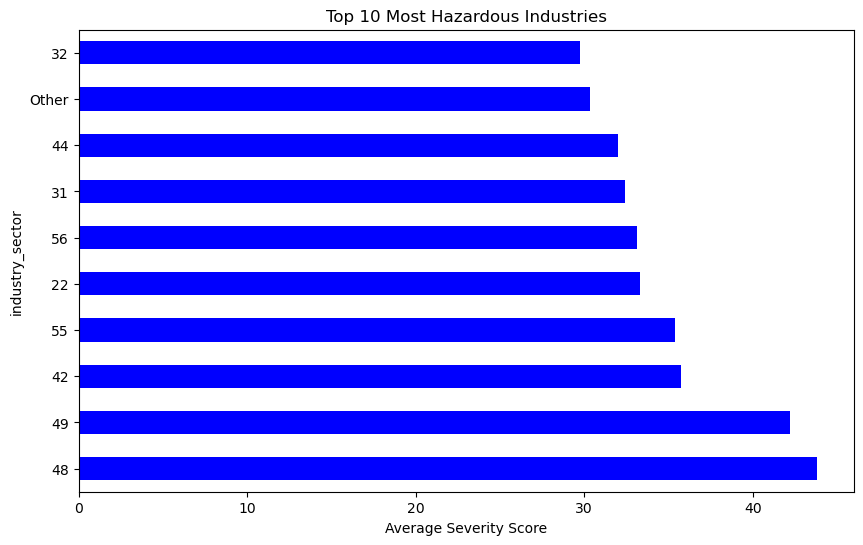

In [46]:
industry_severity.head(10).plot(kind='barh', figsize=(10,6), color='blue')
plt.title("Top 10 Most Hazardous Industries")
plt.xlabel("Average Severity Score")
plt.show()

In [47]:
# Calculate Total Incidents per Industry
industry_stats = df.groupby('industry_sector').agg(
    total_incidents=('severity_score','count'),
    avg_severity=('severity_score','mean')
)

In [48]:
# Create Safety Risk Score
industry_stats['safety_risk_score'] = (
    industry_stats['total_incidents'] * industry_stats['avg_severity']
)

industry_stats = industry_stats.sort_values(by='safety_risk_score', ascending=False)

In [49]:
# industry_stats.head(10)
industry_stats.head(10)

,total_incidents,avg_severity,safety_risk_score
industry_sector,,,
49,124757,42.238848,5269592.0
62,190284,19.402225,3691933.0
48,50241,43.807488,2200932.0
44,57391,31.979492,1835335.0
33,50146,29.544111,1481519.0
45,56639,25.028390,1417583.0
31,33967,32.439603,1101876.0
42,26584,35.729988,949846.0
32,20038,29.740792,595946.0


In [50]:
monthly_risk = df.groupby(['incident_month','industry_sector']).agg(
    total_incidents=('severity_score','count'),
    avg_severity=('severity_score','mean')
).reset_index()

monthly_risk['risk_score'] = monthly_risk['total_incidents'] * monthly_risk['avg_severity']

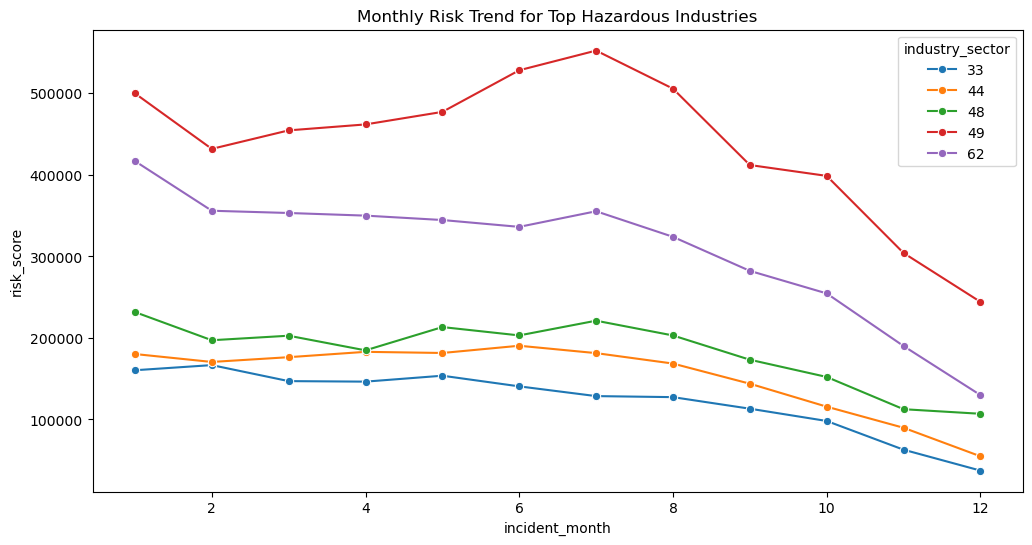

In [51]:
top5 = industry_stats.head(5).index

filtered = monthly_risk[monthly_risk['industry_sector'].isin(top5)]

plt.figure(figsize=(12,6))
sns.lineplot(data=filtered,
             x='incident_month',
             y='risk_score',
             hue='industry_sector',
             marker='o')

plt.title("Monthly Risk Trend for Top Hazardous Industries")
plt.show()

**Interpretation 👇**

* Industry 49 has the highest risk, peaking around Month 6–7, then declining.
* Industry 62 is second highest, showing a gradual decrease over time.
* Industries 48 & 44 have moderate risk with mid-year peaks and later decline.
* Industry 33 has the lowest and steadily decreasing risk.
*  Overall, risk is highest in mid-year (Month 5–7) and improves afterward across all industries.

## Encoding

In [52]:
# Remove the Datetime Column
df = df.drop(columns=['date_of_incident'])
df = df.drop(columns=['establishment_name'])
df = df.drop(columns=['street_address'])
df = df.drop(columns=['city'])
df = df.drop(columns=['naics_code'])
# ------------------------------------------------------
# Encoding Categorical Columns
# ------------------------------------------------------


# 2 Medium Cardinality Columns → Frequency Encoding
# Replaces category values with how often they appear in the dataset
for col in ['industry_description', 'soc_description', 'company_name', 'soc_code']:
    freq = df[col].value_counts()
    df[col] = df[col].map(freq)


# 3 Low Cardinality Columns → One-Hot Encoding
# These columns have few categories, so one-hot encoding works well
df = pd.get_dummies(
    df,
    columns=[
        'shift',
        'size_category',
        'season',
        'establishment_type',
        'soc_reviewed',
        'time_unknown',
        'industry_sector',
        'type_of_incident',
        'naics_year',
        'soc_group'
    ],
    drop_first=True,
    sparse=True
)
# 4 Encode Target Variable
# Convert incident outcome categories into numeric values
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['incident_outcome'] = le.fit_transform(df['incident_outcome'])

In [53]:
# for state and zip_code

zip_coords = pd.read_csv("uszips.csv")
# Keep only required columns
zip_coords = zip_coords[['zip','lat','lng']]
# Rename columns to match dataset
zip_coords.columns = ['zip_code','latitude','longitude']
# Convert zip codes to string (important for merging)
df['zip_code'] = df['zip_code'].astype(str)
zip_coords['zip_code'] = zip_coords['zip_code'].astype(str)
# Merge latitude and longitude with main dataset
df = df.merge(zip_coords, on='zip_code', how='left')
# Fill missing coordinates
df['latitude'] = df['latitude'].fillna(df['latitude'].median())
df['longitude'] = df['longitude'].fillna(df['longitude'].median())
# Drop zip_code after merging
df = df.drop(columns=['zip_code'])
# Check result
df[['latitude','longitude']].head()

# Because latitude and longitude already represent location.
df = df.drop(columns=['state'])

In [54]:
# --------------------------------------------------------
# Text Processing and TF-IDF Feature Creation
# --------------------------------------------------------

# Step 1: Select all text columns related to the incident
text_cols = [
    'job_description',
    'NEW_NAR_WHAT_HAPPENED',
    'NEW_NAR_BEFORE_INCIDENT',
    'NEW_INCIDENT_LOCATION',
    'NEW_NAR_INJURY_ILLNESS',
    'NEW_NAR_OBJECT_SUBSTANCE',
    'NEW_INCIDENT_DESCRIPTION'
]


# Step 2: Combine all text columns into a single column
# This creates one full narrative describing the incident
df['combined_text'] = df[text_cols].astype(str).agg(' '.join, axis=1)


# Step 3: Clean the text
# Convert text to lowercase and remove special characters
import re

df['combined_text'] = df['combined_text'].str.lower()
df['combined_text'] = df['combined_text'].apply(lambda x: re.sub(r'[^a-z\s]', '', x))


# Step 4: Convert text into numerical features using TF-IDF
# Since our dataset has many text columns, using TF-IDF (Term Frequency–Inverse Document Frequency) is a good idea before building the model.
# TF-IDF identifies the most important words across all incident descriptions
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=500, # keep top 500 important words
    min_df = 5,
    max_df = 0.90,
    stop_words='english'   # remove common words like 'the', 'and'
)

tfidf_matrix = tfidf.fit_transform(df['combined_text'])


# Step 5: Convert TF-IDF matrix into a DataFrame
# Each column represents an important keyword
import pandas as pd

tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=tfidf.get_feature_names_out()
)


# Step 6: Reset index before merging
df = df.reset_index(drop=True)
tfidf_df = tfidf_df.reset_index(drop=True)


# Step 7: Merge TF-IDF features with original dataset
df = pd.concat([df, tfidf_df], axis=1)


# Step 8: Drop original text columns since their information is now encoded
df = df.drop(columns=text_cols + ['combined_text'])

## Transformation

In [55]:
# before transformation
num = [
'size',
'annual_average_employees',
'total_hours_worked',
'soc_probability',
'dafw_num_away',
'djtr_num_tr',
'incident_hour',
'start_hour',
'hours_after_start',
'incident_day',
'incident_month',
'incident_year',
'is_weekend',
'working_hour'
]

df[num].skew()

size                        0.716798
annual_average_employees    3.760814
total_hours_worked          4.562368
soc_probability             1.775352
dafw_num_away               3.638847
djtr_num_tr                 3.090792
incident_hour              -0.057910
start_hour                  0.934521
hours_after_start          -1.680037
incident_day                0.246611
incident_month             -0.018261
incident_year              -9.622160
is_weekend                  1.662936
working_hour               -1.250275
dtype: float64

In [56]:
df['employees_log'] = np.log1p(df['annual_average_employees'])
df['hours_log'] = np.log1p(df['total_hours_worked'])
df['soc_prob_log'] = np.log1p(df['soc_probability'])

df.drop(columns=[
    'annual_average_employees',
    'total_hours_worked',
    'soc_probability'
], inplace=True)

## Data Lekage columns

In [57]:
cols_to_drop = ['dafw_num_away', 'djtr_num_tr']
df = df.drop(columns=cols_to_drop)

### See the information and storage

In [58]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 683962 entries, 0 to 683961
Columns: 586 entries, company_name to soc_prob_log
dtypes: Sparse[bool, False](66), float64(508), int32(1), int64(11)
memory usage: 2.7 GB


# Tarin Test Split

In [59]:
# Separate Target
X = df.drop(columns=['incident_outcome'])
y = df['incident_outcome']

In [60]:
# Train-Test Split (Do this before scaling)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(547169, 585)
(136793, 585)
(547169,)
(136793,)


## Scaling

In [61]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Classification Evaluation Function

In [62]:
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    cohen_kappa_score, roc_auc_score, matthews_corrcoef
)
import matplotlib.pyplot as plt
import seaborn as sns

def evaluate_model(model, X_train, X_test, y_train, y_test):
    
    # Train model
    model.fit(X_train, y_train)
    
    # Predictions
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)
    
    # Accuracy
    acc = accuracy_score(y_test, y_pred)
    print("Accuracy:", acc)
    
    # Cohen Kappa
    kappa = cohen_kappa_score(y_test, y_pred)
    print("Cohen Kappa Score:", kappa)
    
    # 🔥 MCC (IMPORTANT)
    mcc = matthews_corrcoef(y_test, y_pred)
    print("MCC Score:", mcc)
    
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    print()
    
    # ROC-AUC
    auc = roc_auc_score(y_test, y_prob, multi_class='ovr')
    print("ROC-AUC Score (OvR):", auc)

# Model Fitting

### First Model
1. Logistic Regression

Accuracy: 0.7165425131402923
Cohen Kappa Score: 0.5750931505147905
MCC Score: 0.5796848292487968

Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.57      0.63     48883
           1       0.04      0.37      0.07        52
           2       0.64      0.62      0.63     41226
           3       0.78      0.96      0.86     46632

    accuracy                           0.72    136793
   macro avg       0.54      0.63      0.55    136793
weighted avg       0.71      0.72      0.71    136793



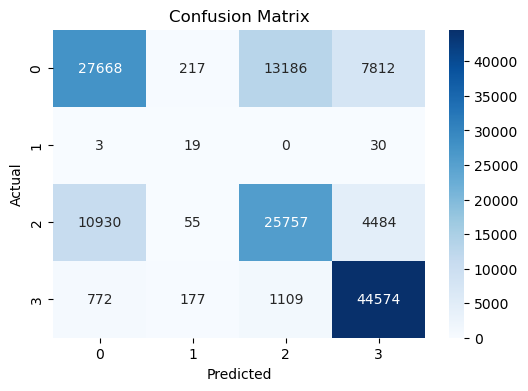


ROC-AUC Score (OvR): 0.8921462784210522


In [63]:
from sklearn.linear_model import LogisticRegression
model_lr = LogisticRegression(max_iter=1000, class_weight='balanced')
evaluate_model(model_lr, X_train_scaled, X_test_scaled, y_train, y_test)

**Model Interpretation**

* The Logistic Regression model achieved an overall accuracy of 72%, indicating a moderate level of performance. However, accuracy alone is not a reliable metric in this case due to the presence of class imbalance in the dataset.
* The Cohen’s Kappa score (0.57) and Matthews Correlation Coefficient (0.58) suggest that the model has a moderate predictive capability, performing better than random guessing but still leaving room for improvement.

**Class-wise Performance**
* The model performs unevenly across different classes:
* Class 0 and Class 2 show moderate performance, with F1-scores around 0.63, indicating a balanced trade-off between precision and recall.
* Class has the best performance, with a high recall of 0.96 and an F1-score of 0.86, meaning most instances of this class are correctly identified.
* Class 1, which is the minority class, shows very poor performance, with an F1-score of only 0.07. This indicates that the model fails to correctly identify this class and is heavily biased toward majority classes.

**Confusion Matrix Analysis**
* The confusion matrix highlights key issues in the model:
* There is significant misclassification between Class 0 and Class 2, suggesting that the model struggles to distinguish between these two categories.
* The model rarely predicts Class 1 correctly, further confirming the impact of class imbalance.
* A large number of samples are correctly classified as Class 3, indicating that the model is biased toward this dominant class.

### Second Model
2. RandomForest

Accuracy: 0.7701709882815642
Cohen Kappa Score: 0.6546404964729591
MCC Score: 0.6563328259519434

Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.75      0.71     48883
           1       0.03      0.69      0.06        52
           2       0.66      0.57      0.61     41226
           3       0.99      0.97      0.98     46632

    accuracy                           0.77    136793
   macro avg       0.59      0.75      0.59    136793
weighted avg       0.78      0.77      0.77    136793



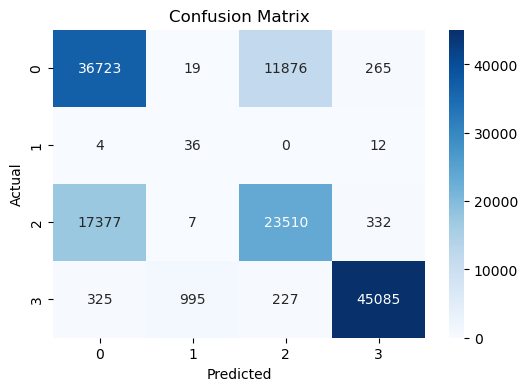


ROC-AUC Score (OvR): 0.9186306325958029


In [64]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,              # prevent overfitting
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight='balanced_subsample',  # better than 'balanced'
    n_jobs=-1,
    random_state=42
)

rf.fit(X_train, y_train)

evaluate_model(rf, X_train, X_test, y_train, y_test)

**Model Interpretation**
* The Random Forest model achieved an overall accuracy of 77%, indicating a reasonably good predictive performance. The Cohen’s Kappa score (0.65) and Matthews Correlation Coefficient (0.65) further suggest that the model has a moderate to strong agreement beyond chance.
* However, a deeper analysis of the classification report reveals class imbalance issues affecting model performance.
* The model performs exceptionally well for Class 3, achieving a very high precision (0.99), recall (0.97), and F1-score (0.98), indicating that the model can accurately identify this class with minimal error.
* For Class 0 and Class 2, the model demonstrates moderate performance, with F1-scores of 0.71 and 0.61, respectively. The confusion matrix shows significant misclassification between these two classes, suggesting that the model struggles to clearly distinguish between them.
* In contrast, Class 1 (minority class) exhibits a critical issue. While the model achieves a relatively high recall (0.69), its precision is extremely low (0.03). This indicates that although the model identifies most actual instances of Class 1, it incorrectly classifies a large number of other instances as Class 1, leading to a high number of false positives. This behavior is primarily due to the severe class imbalance, as Class 1 contains only a very small number of samples.

### Third Model
3. Random Forest with Custom

In [65]:
# ======================================================
# FIXED VERSION (CORRECT THRESHOLD LOGIC)
# ======================================================

import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, matthews_corrcoef

def train_and_evaluate(weight):

    print(f"\n🔍 Testing class 1 weight = {weight}")

    rf = RandomForestClassifier(
        n_estimators=300,
        max_depth=12,
        min_samples_split=10,
        min_samples_leaf=5,
        class_weight={0:1, 1:weight, 2:1, 3:1},
        n_jobs=-1,
        random_state=42
    )

    rf.fit(X_train, y_train)

    y_prob = rf.predict_proba(X_test)

    threshold = 0.6
    y_pred = []

    for prob in y_prob:
        if prob[1] > threshold:
            y_pred.append(1)
        else:
            # FIXED: correct class mapping
            other_probs = [prob[0], prob[2], prob[3]]
            classes = [0, 2, 3]
            y_pred.append(classes[np.argmax(other_probs)])

    y_pred = np.array(y_pred)

    print(classification_report(y_test, y_pred))
    print("MCC:", matthews_corrcoef(y_test, y_pred))


# Run
weights = [10, 20, 30, 40, 50]

for w in weights:
    train_and_evaluate(w)


🔍 Testing class 1 weight = 10
              precision    recall  f1-score   support

           0       0.60      0.92      0.73     48883
           1       0.00      0.00      0.00        52
           2       0.76      0.29      0.42     41226
           3       0.98      0.99      0.99     46632

    accuracy                           0.75    136793
   macro avg       0.59      0.55      0.53    136793
weighted avg       0.78      0.75      0.72    136793

MCC: 0.6577641978413252

🔍 Testing class 1 weight = 20
              precision    recall  f1-score   support

           0       0.60      0.92      0.73     48883
           1       0.00      0.00      0.00        52
           2       0.75      0.29      0.42     41226
           3       0.98      0.99      0.99     46632

    accuracy                           0.75    136793
   macro avg       0.59      0.55      0.53    136793
weighted avg       0.78      0.75      0.72    136793

MCC: 0.6561017228398973

🔍 Testing class 1 w

### Forth Model
4. XGboost

Accuracy: 0.8312486750053
Cohen Kappa Score: 0.7462765240696878
MCC Score: 0.7462772784225211

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.77      0.77     48883
           1       0.00      0.00      0.00        52
           2       0.72      0.72      0.72     41226
           3       0.99      1.00      0.99     46632

    accuracy                           0.83    136793
   macro avg       0.62      0.62      0.62    136793
weighted avg       0.83      0.83      0.83    136793



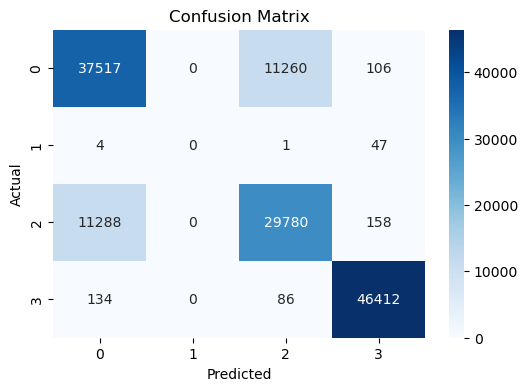


ROC-AUC Score (OvR): 0.9523839045740066


In [66]:
from xgboost import XGBClassifier

# ======================================================
# XGBOOST MODEL
# ======================================================
xgb = XGBClassifier(
    n_estimators=400,          # number of trees
    max_depth=8,               # controls complexity
    learning_rate=0.05,        # slow learning = better accuracy
    subsample=0.8,             # prevents overfitting
    colsample_bytree=0.8,      # feature sampling
    objective='multi:softprob',# multi-class classification
    eval_metric='mlogloss',    # evaluation metric
    n_jobs=-1,
    random_state=42
)

# ======================================================
# TRAIN + EVALUATE
# ======================================================
evaluate_model(xgb, X_train, X_test, y_train, y_test)

**Model Interpretation**
* The model achieved an overall accuracy of 83%, indicating an improvement in predictive performance compared to the previous model. The Cohen’s Kappa score (0.75) and Matthews Correlation Coefficient (0.74) suggest a strong level of agreement and reliable classification performance.
* At the class level, the model performs very well for Class 3, achieving near-perfect results with precision (0.99), recall (1.00), and F1-score (0.99). This indicates that the model is highly effective in identifying this majority class with minimal error.
* Similarly, Class 0 and Class 2 show good and balanced performance, each with F1-scores around 0.77 and 0.72, respectively. However, the confusion matrix indicates some misclassification between these two classes, suggesting moderate overlap in their feature patterns.
* A major limitation of the model is observed in Class 1 (minority class). The model completely fails to predict this class, with precision, recall, and F1-score all equal to 0.00. The confusion matrix confirms that none of the actual Class 1 instances are correctly classified. This issue arises due to extreme class imbalance, where the model becomes biased toward majority classes and ignores the minority class entirely.
* Although the weighted average metrics (0.83) appear strong, they are heavily influenced by the dominant classes and do not reflect the poor performance on the minority class.

## Final Model
5. LightGBM

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 1.986700 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 130002
[LightGBM] [Info] Number of data points in the train set: 547169, number of used features: 585
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further spli

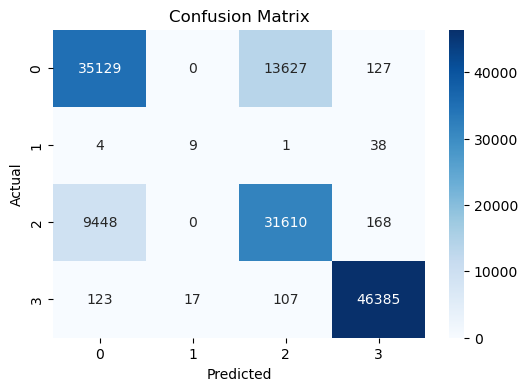


ROC-AUC Score (OvR): 0.9525544316341438


In [67]:
# LIGHTGBM
from lightgbm import LGBMClassifier

lgb = LGBMClassifier(
    n_estimators=400,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight='balanced',
    random_state=42
)

evaluate_model(lgb, X_train, X_test, y_train, y_test)

**Model Interpretation**
* The model achieved an accuracy of 82.7%, indicating strong overall performance. The Cohen’s Kappa (0.74) and MCC (0.74) show good reliability and agreement.
* The model performs exceptionally well for Class 3, with near-perfect scores, and shows good performance for Class 0 and Class 2, though some confusion exists between them.
* For Class 1 (minority class), the model shows slight improvement, with low precision (0.35) and recall (0.17), meaning it detects some cases but still misses many due to class imbalance.
* Overall, the model is well-performing for majority classes, with improved but still weak performance on the minority class, indicating the need for further imbalance handling.

In [1]:
from imblearn.combine import SMOTETomek
from lightgbm import LGBMClassifier

# Step 1: Resample
smt = SMOTETomek(random_state=42)
X_res, y_res = smt.fit_resample(X_train, y_train)

# Step 2: Model
model = LGBMClassifier(
    n_estimators=400,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight='balanced',
    random_state=42)

# Step 3: Train
model.fit(X_res, y_res)
evaluate_model(model, X_train, X_test, y_train, y_test)

NameError: name 'X_train' is not defined